In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import rc
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

In [38]:
#데이터 설명
#2025년 6월 1일 스팀 스토어(비디오 게임 판매 프랫폼) 베스트셀러
#순위 기준 - 판매 수익 기준 (정확히 알려져 있지는 않으나 게임 출시로 
#부터 당시까지의 판매수익이 아닌 임의로 설정된 단기 기간 동안의 판매수익)

#출처- H. Buğra Eken의 Best-Selling Steam Games of All Time
#(Steam, GameFAQs, SteamDB의 데이터 종합)

In [39]:
d=pd.read_csv('bestSelling_games.csv')
d.head(3)

,game_name,reviews_like_rate,all_reviews_number,release_date,developer,user_defined_tags,supported_os,supported_languages,price,other_features,age_restriction,rating,difficulty,length,estimated_downloads
0,Counter-Strike 2,86,8803754,"21 Aug, 2012",Valve,"FPS, Action, Tactical","win, linux","English, Czech, Danish, Dutch, Finnish, French...",0.00,"Cross-Platform Multiplayer, Steam Trading Card...",17,3.20,4,80,306170000
1,PUBG: BATTLEGROUNDS,59,2554482,"21 Dec, 2017",PUBG Corporation,"Survival, Shooter, Action, Tactical",win,"English, Korean, Simplified Chinese, French, G...",0.00,"Online PvP, Stats, Remote Play on Phone, Remot...",13,3.10,4,73,162350000
2,ELDEN RING NIGHTREIGN,77,53426,"30 May, 2025","FromSoftware, Inc.","Souls-like, Open World, Fantasy, RPG",win,"English, Japanese, French, Italian, German, Sp...",25.99,"Single-player, Online Co-op, Steam Achievement...",17,3.96,4,50,840000


In [40]:
#데이터 크기, 정보 확인

In [41]:
print(d.shape)
print(d.info())

(2380, 15)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2380 entries, 0 to 2379
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   game_name            2380 non-null   object 
 1   reviews_like_rate    2380 non-null   int64  
 2   all_reviews_number   2380 non-null   int64  
 3   release_date         2380 non-null   object 
 4   developer            2380 non-null   object 
 5   user_defined_tags    2380 non-null   object 
 6   supported_os         2380 non-null   object 
 7   supported_languages  2380 non-null   object 
 8   price                2380 non-null   float64
 9   other_features       2380 non-null   object 
 10  age_restriction      2380 non-null   int64  
 11  rating               2380 non-null   float64
 12  difficulty           2380 non-null   int64  
 13  length               2380 non-null   int64  
 14  estimated_downloads  2380 non-null   int64  
dtypes: float64(2), int64(6), ob

In [42]:
#결측치 확인

In [43]:
d.isnull().sum()

game_name              0
reviews_like_rate      0
all_reviews_number     0
release_date           0
developer              0
user_defined_tags      0
supported_os           0
supported_languages    0
price                  0
other_features         0
age_restriction        0
rating                 0
difficulty             0
length                 0
estimated_downloads    0
dtype: int64

In [44]:
#중복 데이터 확인

In [45]:
d.duplicated().sum()

np.int64(0)

In [46]:
#머신러닝에 사용할 파생변수 제작

In [47]:
#출시일에서 출시년도와 출시월 추출

In [48]:
d['year']=d['release_date'].astype(str).str.strip().str[-4:].astype('Int64')
d['month'] = d['release_date'].str[-9:-6]
month_dict = {'Jan': 1, 'Feb': 2, 'Mar': 3, 'Apr': 4, 'May': 5, 'Jun': 6,
    'Jul': 7, 'Aug': 8, 'Sep': 9, 'Oct': 10, 'Nov': 11, 'Dec': 12}
d['month'] = d['month'].map(month_dict)
d[['release_date','year','month']].head(3)

,release_date,year,month
0,"21 Aug, 2012",2012,8
1,"21 Dec, 2017",2017,12
2,"30 May, 2025",2025,5


In [49]:
#게임에서 지원하는 언어의 수 연산

In [50]:
d['language_count']=d['supported_languages'].str.split(',').str.len()
d['language_count']=d['language_count'].fillna(0).astype(int)
d[['language_count','supported_languages']].head(3)

,language_count,supported_languages
0,29,"English, Czech, Danish, Dutch, Finnish, French..."
1,17,"English, Korean, Simplified Chinese, French, G..."
2,15,"English, Japanese, French, Italian, German, Sp..."


In [51]:
#게임에서 지원하는 장르의 수 연산

In [52]:
d['genre_count'] = d['user_defined_tags'].str.split(',').str.len()
d[['genre_count','user_defined_tags']].head(3)

,genre_count,user_defined_tags
0,3,"FPS, Action, Tactical"
1,4,"Survival, Shooter, Action, Tactical"
2,4,"Souls-like, Open World, Fantasy, RPG"


In [53]:
#게임 이름의 글자 수 연산

In [54]:
d['name_len']=d['game_name'].str.len()
d[['name_len','game_name']].head(3)

,name_len,game_name
0,16,Counter-Strike 2
1,19,PUBG: BATTLEGROUNDS
2,21,ELDEN RING NIGHTREIGN


In [55]:
#판매량 대비 리뷰수를 새 변수로 추출

In [56]:
d['review_efficiency'] = d['all_reviews_number']/d['estimated_downloads']
d[['review_efficiency','all_reviews_number','estimated_downloads']].head(3)

,review_efficiency,all_reviews_number,estimated_downloads
0,0.028754,8803754,306170000
1,0.015734,2554482,162350000
2,0.063602,53426,840000


In [57]:
#변수 설명
#단 평가, 난이도, 필요 플레이 타임의 경우 해당 게임이나 스팀에서 직접 제공하는 것이 아닌 
#GameFAQs(비디오 게임을 다루는 외부 웹사이트)에서 제공하는 데이터
#예상된 다운로드 건수는 SteamDB(스팀의 데이터를 수집, 제공하는 비공식 통계 사이트)에서 제공

In [58]:
list(d.columns)

['game_name',
 'reviews_like_rate',
 'all_reviews_number',
 'release_date',
 'developer',
 'user_defined_tags',
 'supported_os',
 'supported_languages',
 'price',
 'other_features',
 'age_restriction',
 'rating',
 'difficulty',
 'length',
 'estimated_downloads',
 'year',
 'month',
 'language_count',
 'genre_count',
 'name_len',
 'review_efficiency']

In [59]:
c=pd.DataFrame({'영문':list(d.columns),
                '한글':['게임 이름','리뷰수 대비 좋아요 비율(%)','리뷰 수','출시일',
                '개발사','게임 유저가 직접 지정한 태그(장르)','지원 os','지원 언어',
                '가격($)',' 기타 사항','연령 제한','평가','난이도',
                '필요 플레이 타임','예상된 다운로드 건수 (판매량)','출시년도', '출시월',
                '지원 언어 수','지원 장르의 수','게임 이름 글자 수','판매량 대비 리뷰수']})
c

,영문,한글
0,game_name,게임 이름
1,reviews_like_rate,리뷰수 대비 좋아요 비율(%)
2,all_reviews_number,리뷰 수
3,release_date,출시일
4,developer,개발사
5,user_defined_tags,게임 유저가 직접 지정한 태그(장르)
6,supported_os,지원 os
7,supported_languages,지원 언어
8,price,가격($)
9,other_features,기타 사항


In [60]:
d.describe()

,reviews_like_rate,all_reviews_number,price,age_restriction,rating,difficulty,length,estimated_downloads,year,month,language_count,genre_count,name_len,review_efficiency
count,2380.000000,2.380000e+03,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000,2.380000e+03,2380.0,2380.000000,2380.000000,2380.000000,2380.000000,2380.000000
mean,82.413445,3.161508e+04,10.509130,10.605462,3.228017,2.864706,22.965126,2.523007e+06,2020.386555,6.607563,10.941176,3.150000,18.412605,0.025289
std,12.643745,2.137197e+05,11.344576,6.395752,0.771203,0.975194,21.247556,1.118283e+07,4.809195,3.383407,13.176491,1.028687,10.019376,0.481985
min,20.000000,1.000000e+01,0.000000,0.000000,0.390000,1.000000,1.000000,9.000000e+01,1994.0,1.000000,1.000000,1.000000,2.000000,0.000082
25%,76.000000,3.420000e+02,2.990000,10.000000,2.750000,2.000000,6.000000,3.500000e+04,2018.0,4.000000,4.000000,2.000000,11.000000,0.006781
50%,85.000000,2.106500e+03,7.990000,13.000000,3.380000,3.000000,16.000000,2.171500e+05,2022.0,6.000000,10.000000,3.000000,16.000000,0.011730
75%,92.000000,1.303000e+04,12.490000,17.000000,3.810000,3.000000,34.000000,1.380000e+06,2024.0,10.000000,13.000000,4.000000,24.000000,0.018738
max,100.000000,8.803754e+06,79.990000,17.000000,4.830000,5.000000,80.000000,3.061700e+08,2025.0,12.000000,103.000000,7.000000,108.000000,23.383333


In [61]:
#이상치 확인

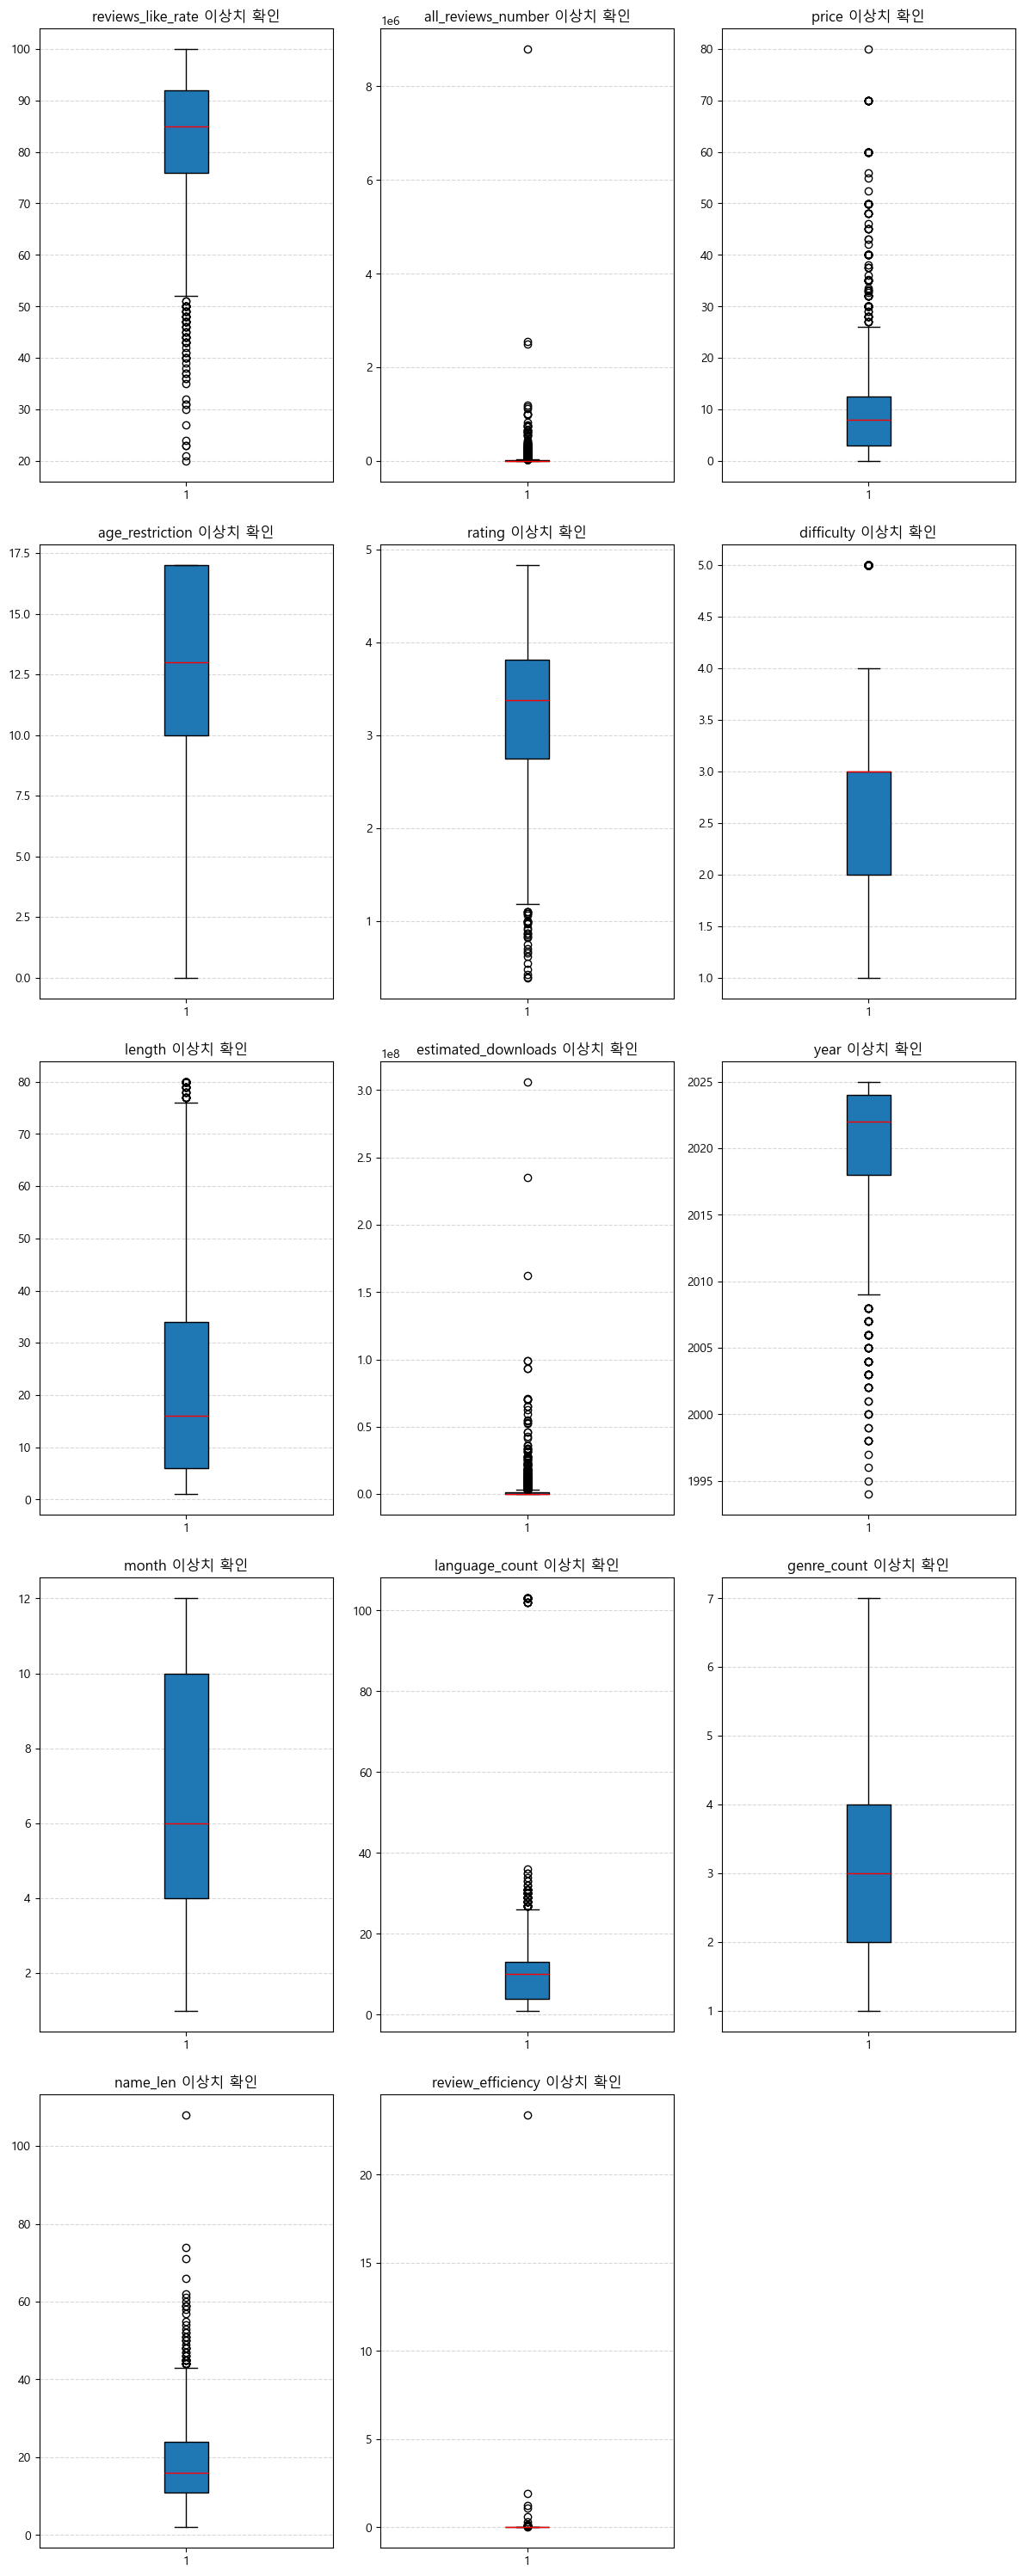

In [62]:
numeric_cols=d.select_dtypes(include=['number']).columns
n_cols = 3
n_rows = len(numeric_cols)
plt.figure(figsize=(12, n_rows * 6))

for i, col in enumerate(numeric_cols):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    
    box = ax.boxplot(d[col].dropna(), patch_artist=True)

    box['medians'][0].set_color('red')         
    
    ax.set_title(f'{col} 이상치 확인', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [63]:
#총 리뷰 수(all_reviews_number)와 판매량(estimated_downloads), 판매량 대비 리뷰수(review_efficiency)
#이상치 처리 필요 확인

In [64]:
#대부분의 게임은 총 리뷰수와 판매량이 매우 낮은 쪽으로 치우쳐져 있고 
#소수의 게임들만이 높은 리뷰수와 판매량을 보임
#해당 속성값을 사이의 격차를 줄이고 이상치의 영향력을 줄이기 위해 로그 변환
d['log_reviews']=np.log(d['all_reviews_number'])
d['log_downloads']=np.log(d['estimated_downloads'])

In [65]:
#판매량 대비 리뷰수의 경우 1보다 큰 즉 리뷰수가 판매량보다 많은, 잘못된 데이터
#들을 확인해서 제거 한 후 로그 변환
d[d['review_efficiency']>=1][['all_reviews_number','estimated_downloads']]

,all_reviews_number,estimated_downloads
11,578396,301000
508,5612,240
2032,1507,1400
2080,1849,1519


In [66]:
d=d[d['review_efficiency']<=1]
d['log_review_efficiency'] = d['log_reviews'] - d['log_downloads']
d[['all_reviews_number','log_reviews','estimated_downloads','log_downloads',
   'log_review_efficiency','review_efficiency']].head(3)

,all_reviews_number,log_reviews,estimated_downloads,log_downloads,log_review_efficiency,review_efficiency
0,8803754,15.990689,306170000,19.539651,-3.548962,0.028754
1,2554482,14.753360,162350000,18.905265,-4.151905,0.015734
2,53426,10.886053,840000,13.641157,-2.755104,0.063602


In [67]:
#지원 언의 수 경우 소수의 게임이 100개 이상의 언어를 지원하고 있는데 이는 
#퍼즐, 캐주얼 장르게임의 특성으로 보여 단순히 제거하는 것보다 로그 변환후 
#게임 장르를 더미변수로 만들어 데이터에 추가하는 것이 적절해보임

In [68]:
d['language_count_m'] = d['language_count'].copy()
d['language_count_m'] =np.log(d['language_count_m'])
d[['language_count', 'language_count_m']]

,language_count,language_count_m
0,29,3.367296
1,17,2.833213
2,15,2.708050
3,25,3.218876
4,13,2.564949
...,...,...
2375,1,0.000000
2376,29,3.367296
2377,8,2.079442
2378,13,2.564949


In [69]:
#전처리 진행한 변수의 이상치 확인
#적절히 처리된 것을 확인

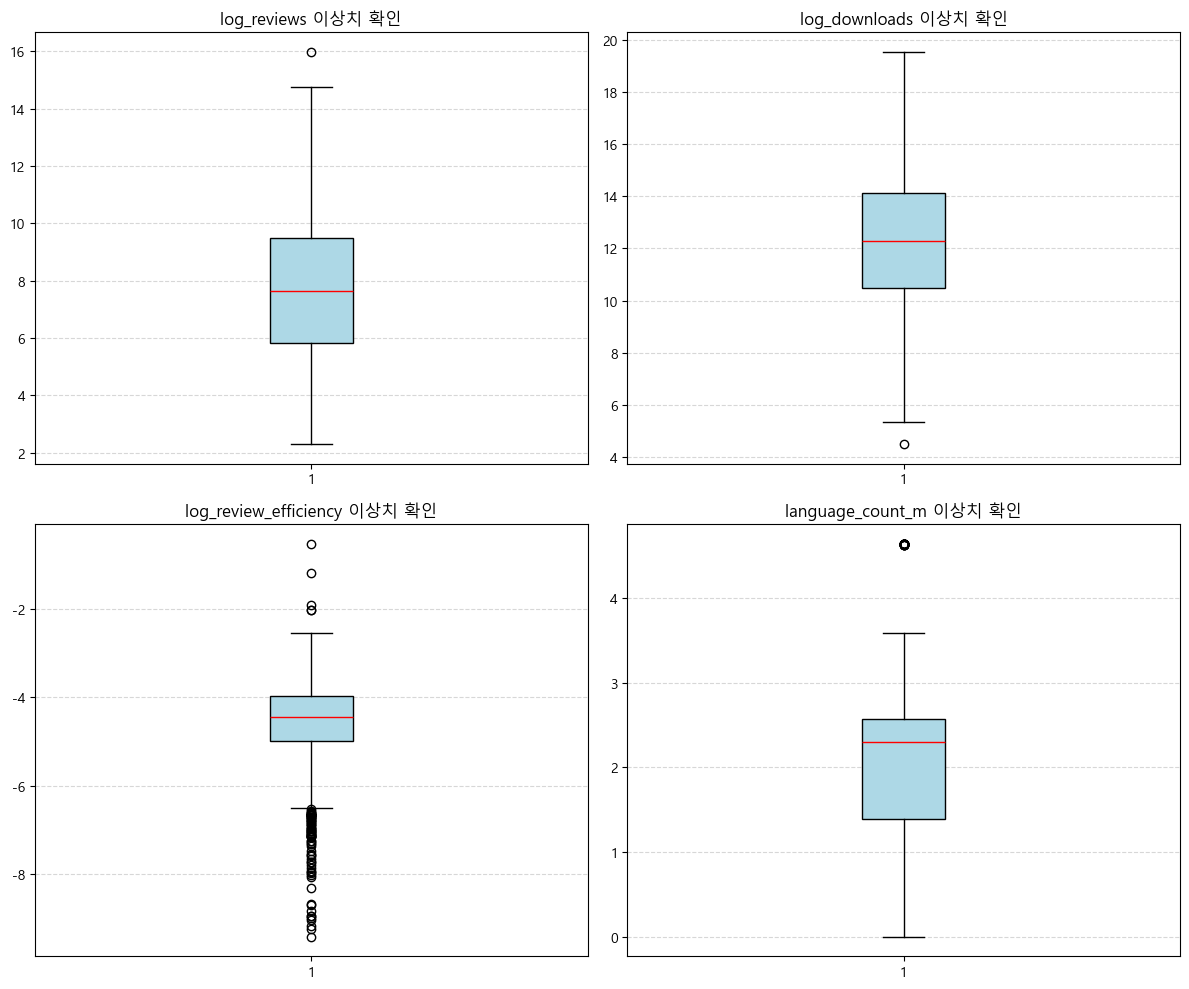

In [70]:
plt.figure(figsize=(12, 10))
n_rows = 2
n_cols = 2
for i, col in enumerate(['log_reviews','log_downloads'
                         ,'log_review_efficiency','language_count_m']):
    ax = plt.subplot(n_rows, n_cols, i + 1)
    
    box = ax.boxplot(d[col].dropna(), patch_artist=True)
    
    box['boxes'][0].set_facecolor('lightblue') 
    box['medians'][0].set_color('red')         
    
    ax.set_title(f'{col} 이상치 확인', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [71]:
#게임 장르 더미화
#게임 유저가 직접 지정한 태그 자체는 수가 너무 많기에 판매량이 높은 상위 10개의 장르
#'Action', 'Fps', 'Survival', 'Open World', 'RPG', 'Simulation', 'Tactical', 
#'Strategy','Adventure','Sandbox'만 더미화시켜 변수로 사용하기로 함

In [72]:
d['genre_list'] = d['user_defined_tags'].str.split(',')
d_exploded=d.explode('genre_list')
d_exploded['genre_list'] = d_exploded['genre_list'].str.strip()
d_exploded=d_exploded[d_exploded['genre_list']!='']
genre_stats = d_exploded.groupby('genre_list')['estimated_downloads'].agg(['count', 'sum'])
genre_stats.columns=['Game_Count', 'Total_Sales']
genre_stats.sort_values('Total_Sales', ascending=False).head(10)

,Game_Count,Total_Sales
genre_list,,
Action,730,2998053247
FPS,247,1815037440
Survival,236,1436812750
Open World,236,1407211540
RPG,440,1156106000
Simulation,737,1128868652
Tactical,93,851904080
Strategy,352,803955808
Adventure,522,700940730


In [73]:
from sklearn.preprocessing import MultiLabelBinarizer

target_g = ['Action', 'FPS', 'Survival', 'Open World', 'RPG', 'Simulation', 'Tactical', 'Strategy', 'Adventure', 'Sandbox']

d['genre_list'] = d['user_defined_tags'].apply(lambda x: [g.strip() for g in str(x).split(',')] if isinstance(x, str) else x)

mlb = MultiLabelBinarizer(classes=target_g)

dummy_matrix = mlb.fit_transform(d['genre_list'])

genre_dummy = pd.DataFrame(dummy_matrix, columns=mlb.classes_)
d = pd.concat([d.reset_index(drop=True), genre_dummy], axis=1)

# 결과 확인
d

C:\Users\oyooy\anaconda3\envs\sstat\Lib\site-packages\sklearn\preprocessing\_label.py:1007: UserWarning: unknown class(es) ['', '2.5D', '2D', 'Anime', 'Automation', 'Building', 'CRPG', 'Card Game', 'Combat', 'Crafting', 'Cute', 'Driving', 'Early Access', 'Fantasy', 'Fighting', 'Horror', 'JRPG', 'MMORPG', 'Management', 'Pixel Graphics', 'Platformer', 'Puzzle', 'Realistic', 'Roguelike', 'Sexual Content', 'Shooter', 'Souls-like', 'Sports', 'Stealth', 'Story Rich', 'Turn-Based', 'Visual Novel', 'War'] will be ignored
  warnings.warn(


,game_name,reviews_like_rate,all_reviews_number,release_date,developer,user_defined_tags,supported_os,supported_languages,price,other_features,...,Action,FPS,Survival,Open World,RPG,Simulation,Tactical,Strategy,Adventure,Sandbox
0,Counter-Strike 2,86,8803754,"21 Aug, 2012",Valve,"FPS, Action, Tactical","win, linux","English, Czech, Danish, Dutch, Finnish, French...",0.00,"Cross-Platform Multiplayer, Steam Trading Card...",...,1,1,0,0,0,0,1,0,0,0
1,PUBG: BATTLEGROUNDS,59,2554482,"21 Dec, 2017",PUBG Corporation,"Survival, Shooter, Action, Tactical",win,"English, Korean, Simplified Chinese, French, G...",0.00,"Online PvP, Stats, Remote Play on Phone, Remot...",...,1,0,1,0,0,0,1,0,0,0
2,ELDEN RING NIGHTREIGN,77,53426,"30 May, 2025","FromSoftware, Inc.","Souls-like, Open World, Fantasy, RPG",win,"English, Japanese, French, Italian, German, Sp...",25.99,"Single-player, Online Co-op, Steam Achievement...",...,0,0,0,1,1,0,0,0,0,0
3,The Last of Us™ Part I,79,45424,"28 Mar, 2023",Naughty Dog LLC,"Story Rich, Shooter, Survival, Horror",win,"English, Italian, Spanish - Spain, Czech, Dutc...",59.99,"Single-player, Steam Achievements, Steam Tradi...",...,0,0,1,0,0,0,0,0,0,0
4,Red Dead Redemption 2,92,672140,"5 Dec, 2019",Rockstar Games,"Open World, Story Rich, Adventure, Realistic, ...",win,"English, French, Italian, German, Spanish - Sp...",59.99,"Single-player, Online PvP, Online Co-op, Steam...",...,0,0,0,1,0,0,0,0,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2371,Wooden House,38,147,"5 Sep, 2016",GDNomaD,Simulation,win,English,0.89,"Single-player, Steam Trading Cards, Family Sha...",...,0,0,0,0,0,1,0,0,0,0
2372,Shoot. Push. Repeat.,84,65,"8 Jun, 2020",CrewLab,"Puzzle, 2D",win,"English, French, Italian, German, Spanish - Sp...",0.89,"Single-player, Steam Achievements, Steam Cloud...",...,0,0,0,0,0,0,0,0,0,0
2373,X2: The Threat,83,416,"3 Dec, 2003",Egosoft,"Strategy, Simulation",win,"English, French, German, Italian, Spanish - Sp...",2.99,"Single-player, Captions available, Steam Cloud...",...,0,0,0,0,0,1,0,1,0,0
2374,!AnyWay!,71,498,"6 Jun, 2018",EYEFRONT,"Platformer, 2D",win,"English, Russian, French, Italian, German, Pol...",1.35,"Single-player, Steam Achievements, Steam Tradi...",...,0,0,0,0,0,0,0,0,0,0


In [74]:
#분석 목적/인사이트 설명 - 게임의 장르, 가격, 좋아요 비율, 출시연도 등의 특성이  
#판매량(예상된 다운로드 건수)에 어떤 영향을 미치는 지 파악

In [75]:
#게임의 가격과 판매량의 상관관계

In [76]:
#무료 게임 포함시 게임 가격과 판매량간의 약한 상관관계를 보임

                  price  log_downloads
price          1.000000       0.309269
log_downloads  0.309269       1.000000


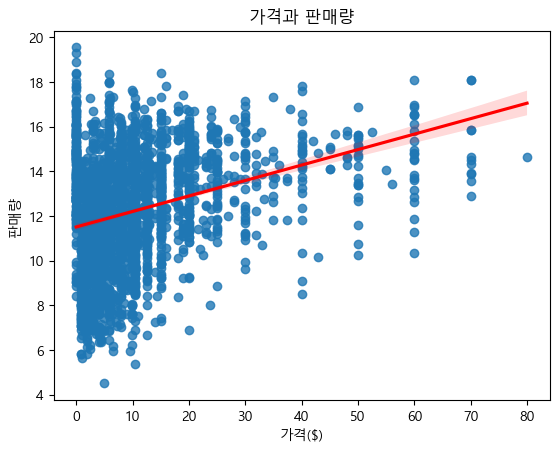

In [77]:
print(d[['price','log_downloads']].corr())
sns.regplot(x='price', y='log_downloads', data=d, line_kws={'color':'red'})
plt.title('가격과 판매량')
plt.xlabel('가격($)')
plt.ylabel('판매량')
plt.show()

In [78]:
#무료 게임을 제외하면 게임 가격과 판매량간의 상관관계가 약간 상승
#하지만 높은 게임 가격이 게임 제작 및 홍보비의 영향이라고 볼때 
#게임 시장은 자본의 크기에 영향을 받으면서도 다른 변수의 영향도 있을 것으로 예상됨

                  price  log_downloads
price          1.000000       0.393423
log_downloads  0.393423       1.000000


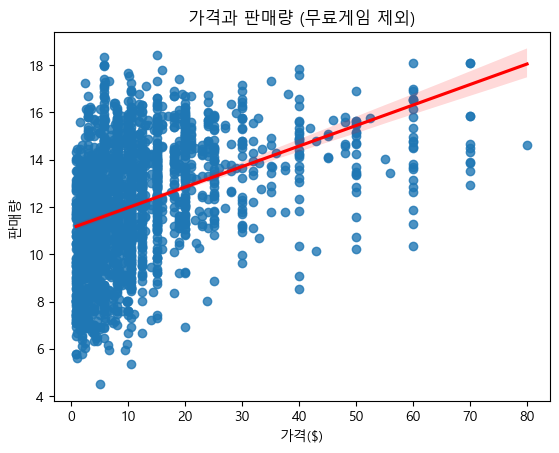

In [79]:
paidgame=d[d['price'] > 0]
print(paidgame[['price','log_downloads']].corr())
sns.regplot(x='price', y='log_downloads', data=paidgame, line_kws={'color':'red'})
plt.title('가격과 판매량 (무료게임 제외)')
plt.xlabel('가격($)')
plt.ylabel('판매량')
plt.show()

In [80]:
#게임의 지원언어의 수와 판매량의 상관관계

In [81]:
#이상치를 제거해도 약한 상관관계를 보임
#다양한 국가의 구매자들을 겨냥해 많은 언어를 지원
#해도 판매량과 직접적인 관련이 있다고 보기 어려움

                  language_count_m  log_downloads
language_count_m          1.000000       0.186821
log_downloads             0.186821       1.000000


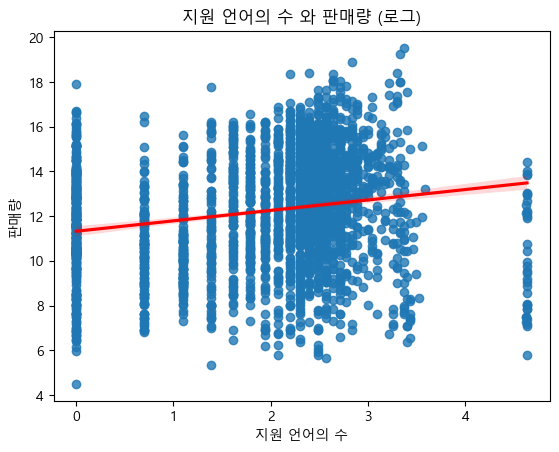

In [82]:
print(d[['language_count_m','log_downloads']].corr())
sns.regplot(x='language_count_m', y='log_downloads', data=d, line_kws={'color':'red'})
plt.title('지원 언어의 수 와 판매량 (로그)')
plt.xlabel('지원 언어의 수')
plt.ylabel('판매량')

plt.show()

In [83]:
#장르와 판매량의 상관관계

In [84]:
#게임의 지원 장르의 수와 판매량의 상관관계
#두 변수 사이의 약한 상관관계를 확인할 수 있을 뿐
#지원 장르의 수가 판매량의 주요 요인이라고 보기 힘듬

               genre_count  log_downloads
genre_count       1.000000       0.207469
log_downloads     0.207469       1.000000


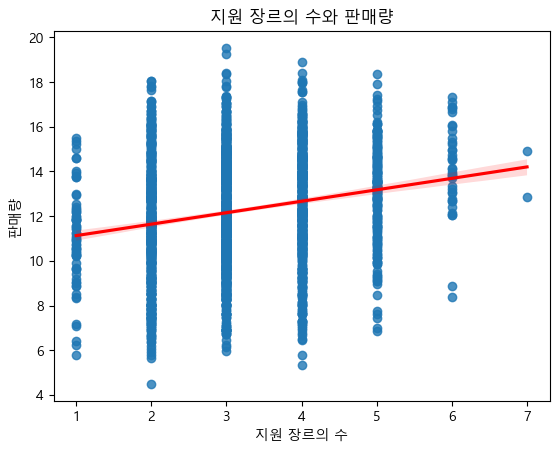

In [85]:
print(d[['genre_count','log_downloads']].corr())
sns.regplot(x='genre_count', y='log_downloads', data=d, line_kws={'color':'red'})
plt.title('지원 장르의 수와 판매량')
plt.xlabel('지원 장르의 수')
plt.ylabel('판매량')

plt.show()

In [86]:
#번외로 장르별 게임 수와 판매량의 상관관계를 한번 알아보도록 함

In [87]:
#먼저 장르별 게임수 및 판매량 계산

In [88]:
#장르별 게임수와 판매량의 상관관계
#다른 상관관계들과 비교해 보았을 때 비교적 강한 상관관계를 확인 할 수 있음
#즉 게임이 많이 출시되는 장르가 시장 규모도 그만큼 크다는 것을 보여줌
#현재 게임 시장의 새로운 시도가 부족하고 획일적인 게임들이 다수인 이유라고 볼 수 있음

                 Game_Count  Total_Sales_Log
Game_Count         1.000000         0.640799
Total_Sales_Log    0.640799         1.000000


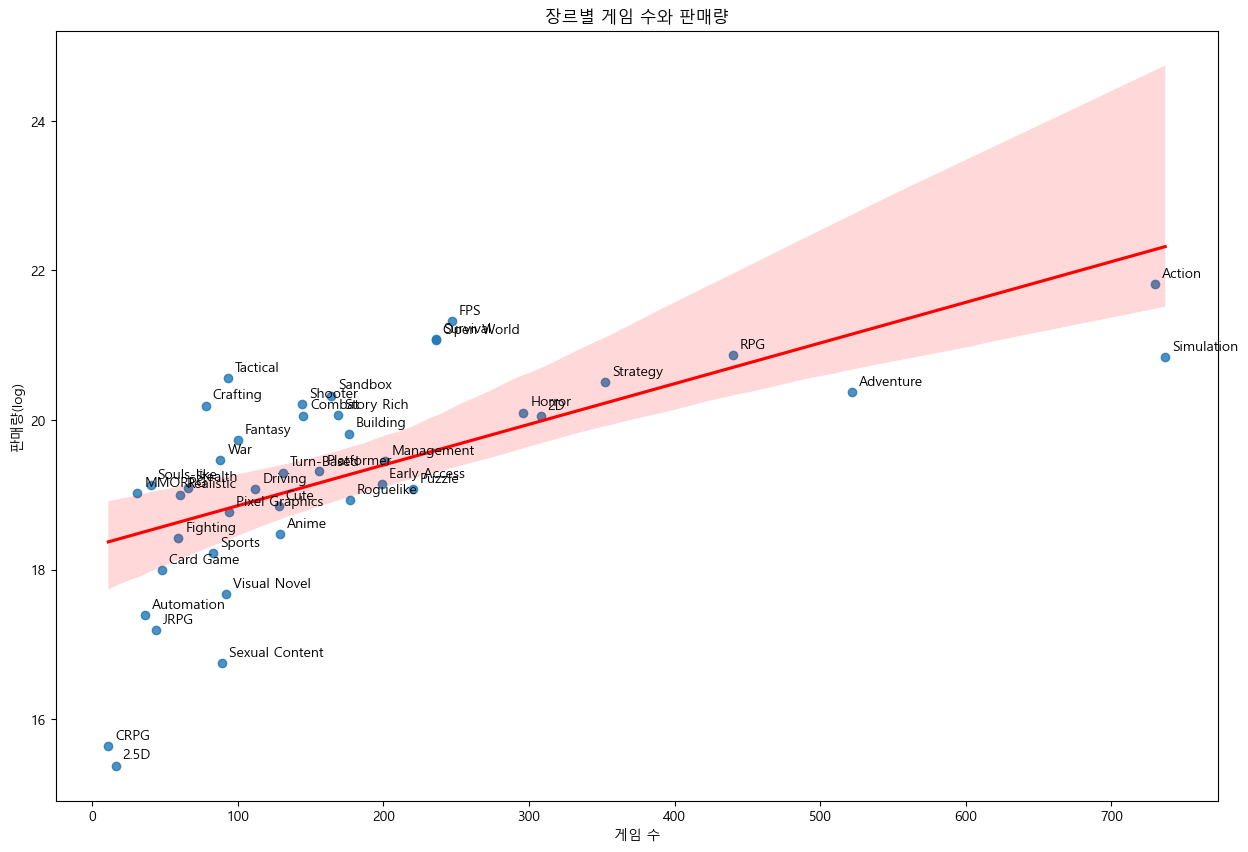

In [89]:
genre_stats['Total_Sales_Log'] = np.log(genre_stats['Total_Sales'])
print(genre_stats[['Game_Count','Total_Sales_Log']].corr())
plt.figure(figsize=(15, 10))
sns.regplot(x='Game_Count', y='Total_Sales_Log', data=genre_stats, line_kws={'color':'red'})

for i, txt in enumerate(genre_stats.index):
    plt.annotate(txt, (genre_stats['Game_Count'].iat[i], genre_stats['Total_Sales_Log'].iat[i]), 
                 xytext=(5, 5), textcoords='offset points')

plt.title('장르별 게임 수와 판매량')
plt.xlabel('게임 수')
plt.ylabel('판매량(log)')
plt.show()

In [90]:
#여러 변수들과 판매량 사이의 상관관계를 보았을 때
#어떤 한 변수가 판매량을 설명하기 힘들다는 것을 확인
#그렇기에 여러 변수들과 판매량 사이의 관계를 알아보기 위해
#지도학습 회귀 머신러닝을 사용하기로 함

In [91]:
#판매량에 의미있는 영향력을 미치는 변수를 찾기 위해서는 릿지보다 의미없는 변수의 계수는 
#0으로 만들고 다중공선성 문제 해결에 좋은 랏소를 사용
#추가적으로 선형모델과 비선형모델 알고리즘을 비교해보기 위해 전처리가 크게 필요없는 
#램덤포레스트를 사용하기로 함

In [92]:
#랏소

In [93]:
#분석에 사용할 독립 변수
    #다운로드 수 대비 리뷰 수(로그), 출시 년도, 제목 글자 수, 좋아요 비율, 가격, 연령 제한, 평가, 
    #난이도, 필요 플레이 타임,지원 장르 수, 지원 언어 수(로그), 출시 월

#분석에 사용할 종속 변수
    #예상된 다운로드 건수 (판매량)(로그)

In [94]:
features = ['log_review_efficiency','year','name_len','reviews_like_rate', 'price', 
            'age_restriction', 'rating', 'difficulty', 'length', 'genre_count', 
            'language_count_m','month','Action', 'FPS', 'Survival', 'Open World', 'RPG', 'Simulation', 'Tactical', 'Strategy', 'Adventure', 'Sandbox']

In [95]:
#전체에서 20%를 테스트용으로 분리

In [96]:
x=d[features]
y=d['log_downloads']
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(
        x, y, test_size=0.2, random_state=42)

In [97]:
#훈련 데이터 기준으로 스케일링 진행

In [98]:
from sklearn.preprocessing import StandardScaler
ss=StandardScaler()
ss.fit(train_input)
train_scaled=ss.transform(train_input)
test_scaled=ss.transform(test_input)

In [99]:
#alpha는 랏소 회귀에서 변수들의 계수를 0으로 처리할 때의 기준으로 정규화 강도를 조절하는 값으로, 
#alpha가 클수록 더 많은 변수의 계수가 0으로 수렴시
#최적의 alpha값을 찾기 위해 0.001 부터 100까지의 alpha값을 준비하고 하나씩 대입해보면서
#교차검증 랏소 회귀 시행 

In [100]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_validate
train_scores=[]
test_scores=[]
alpha_list = [0.001, 0.01, 0.1, 1, 10, 100]
for alpha in alpha_list:
    lasso=Lasso(alpha=alpha, max_iter=10000)
    scores = cross_validate(lasso, train_scaled, train_target,
    return_train_score=True)
    train_scores.append(scores['train_score'].mean())
    test_scores.append(scores['test_score'].mean())

In [101]:
#alpha 값 시각화 및 최적의 alpha값 선택
#alpha 값에 따른 훈련 세트와 검증 세트의 점수를 비교하여 과대적합(훈련 점수 > 검증 점수)과 
#과소적합(두 점수 모두 낮음)을 피하는 최적의 alpha 값 (이때 점수란 R^2, 즉 결정계수)
#설명력으로 추정한 회귀식, 모형에서 독립변수가 종속변수의 변화를 얼마나 잘 설명 또는 
#예측하는지 나타내는 정도를 말함

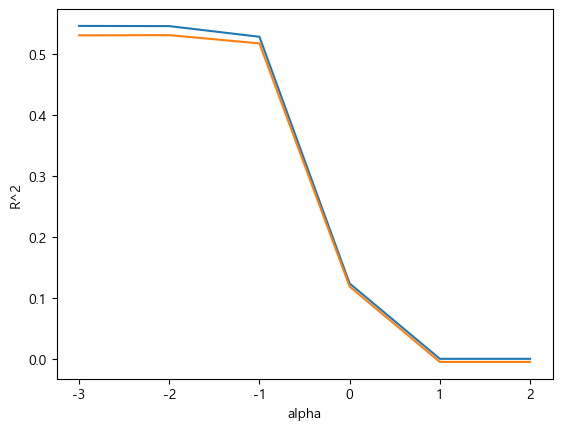

검증 점수가 가장 높은 alpha: 0.01
훈련 점수: 0.5456
검증 점수: 0.5308


In [102]:
plt.plot(np.log10(alpha_list), train_scores)
plt.plot(np.log10(alpha_list), test_scores)
plt.xlabel('alpha')
plt.ylabel('R^2')
plt.show()
best_idx = np.argmax(test_scores)
best_alpha = alpha_list[best_idx]

print(f"검증 점수가 가장 높은 alpha: {best_alpha}")
print(f"훈련 점수: {train_scores[best_idx]:.4f}")
print(f"검증 점수: {test_scores[best_idx]:.4f}")

In [103]:
#최종 모델 평가: 알파값 중 0.01일때 훈련 세트와 최종 테스트 세트간 정확도 차이가 작으며 (과대적합X)
#               검증점수가 가장 높음(과소적합X)

In [104]:
#0.01을 알파값으로 사용해 모델 학습
#모델이 데이터의 약 절반 정도 변동을 설명

In [105]:
lasso = Lasso(alpha=best_alpha, max_iter=10000)
lasso.fit(train_scaled, train_target)
print(lasso.score(train_scaled, train_target))
print(lasso.score(test_scaled, test_target))

0.5442873888911937
0.5304517750013205


In [106]:
#단 한개의 변수, month의 계수만 0으로 처리되었음
#즉 게임의 출시 월의 경우 변수로서 의미가 없음을 알 수 있음
#나머지 10개의 변수가 모두 의미있게 예측에 기여, 이 변수 이외의 변수 계수를
#인위적으로 0으로 만든다면 모델의 예측 실력이 오히려 떨어짐

In [107]:
print(np.sum(lasso.coef_==0))
dead_features = train_input.columns[lasso.coef_ == 0]
print(dead_features.tolist())

1
['month']


In [108]:
#계수들을 중요도순으로 보기위해 내림차순으로 정렬
#(스케일링 거친 데이터 이기에 이미 계수도 표준화 되어있음)

In [109]:
#계수 해석
#게임 플레이 타임이 길수록 누적 판매량에 긍정적 영향을 주며 이는 숏폼이 크게 유행하는 요즘 
#미디어 시장과 구별되는 게임 이용자들의 성향때문이라고 할 수 있음
#또한 출시 년도의 계수가 음수 인것을 통해 알 수 있듯 게임은 시장에 오래 살아남아 스테디셀러로 자리잡는 것이 판매량 확보에 유리함을 알 수 있음
#지원하는 언어의 수, 좋아요 비율, 평가, 지원 장르 수는 높을 수록 누적 판매량에 당연하게 긍정적 영향을 미쳤고
#그중 지원 언어의 수가 전체에서 4등으로 높은 중요도를 보인것을 통해 스팀이 전세계의 나라에서 사용할 수 있는 게임 판매 플랫폼이기에 
#다양한 국가의 소비자를 확보하는 것이 중요함을 알 수 있음
#의외로 가격과 연령 제한,난이도도 높을 수록 누적 판매량이 높은 것으로 나타남
#이는 스팀 이용자들이 주로 성인이기에 연령제한에 대상이 아니며
#퀄리티가 높고 현실적이고 자극적인 비싼 가격의 게임들을 선호한다는 것을 보여줌
#또한 판매량 대비 리뷰수의 경우 음수로 나타났는데 이는 대다수의 소비자가 구매물품에 리뷰를 달지 않듯
#판매량 대비 리뷰수가 많은 게임이 다수의 사람보다는 특정 매니아층에게만 소비되고 있음을 시사함
#장르의 경우 FPS장르의 계수가 가장 컸으며 Adventure와 Strategy의 경우 계수가 음수로 해당 장르를 지원한다면
#판매량이 줄어든다는 것을 알 수 있음

In [110]:
col_l=pd.DataFrame({'변수':features, '계수': lasso.coef_})
col_l['절대값_계수']=col_l['계수'].abs()
lasso_coef=col_l[['변수','계수','절대값_계수']].sort_values('절대값_계수',ascending=False)
lasso_coef

,변수,계수,절대값_계수
8,length,0.823065,0.823065
1,year,-0.682507,0.682507
0,log_review_efficiency,-0.515769,0.515769
10,language_count_m,0.482023,0.482023
4,price,0.354352,0.354352
3,reviews_like_rate,0.327178,0.327178
6,rating,0.271981,0.271981
13,FPS,0.237453,0.237453
2,name_len,-0.186796,0.186796
15,Open World,0.178328,0.178328


In [111]:
#변수의 계수가 양수면 파란색, 음수면 붉은색으로 표시하여
#막대그래프로 표시

C:\Users\oyooy\AppData\Local\Temp\ipykernel_26004\3955746856.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='절대값_계수',y='변수', data=lasso_coef, palette=colors)


<Axes: xlabel='절대값_계수', ylabel='변수'>

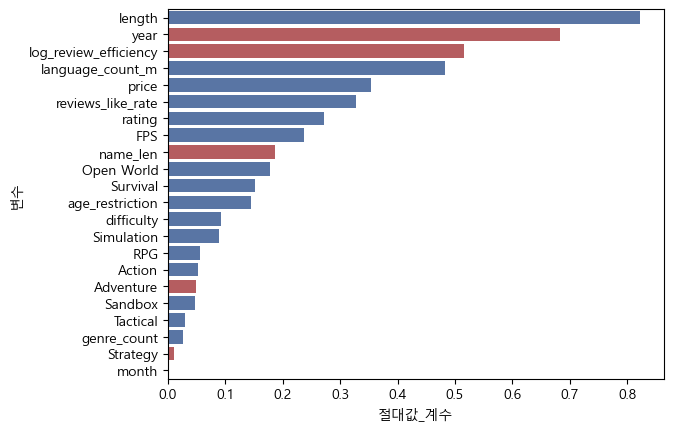

In [112]:
colors = ['#4C72B0' if x > 0 else '#C44E52' for x in lasso_coef['계수']]
sns.barplot(x='절대값_계수',y='변수', data=lasso_coef, palette=colors)

In [113]:
# 오분류 분석 - 오차가 가장 큰 상위 3개 게임
#전반적으로 데이터들이 회귀선 주위에 분포 하지만 일부 실제 판매량이 높은 게임을 과소평가하는
#경향이 나타난 것으로 보아 모델에 포함시키지 못한 독립변수가 있다는 것을 알 수 있음

오차가 가장 큰 상위 3개 게임
                                                     이름  실제 누적 판매량  예상 누적 판매량  \
290   Business Tour - Board Game with Online Multipl...  16.134953  10.625860   
1321                                          Helltaker  15.545395  10.133088   
332                                            Mystopia   4.499810   9.405087   

        잔차 절대값  
290   5.509092  
1321  5.412306  
332   4.905278  


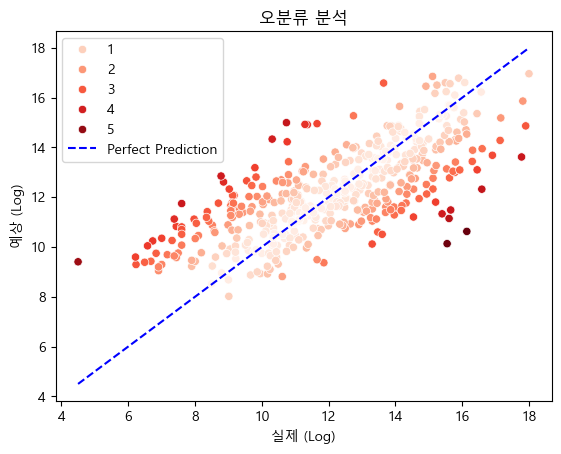

In [114]:
#테스트 세트에 대한 예측값 계산
y_pred_l = lasso.predict(test_scaled)

#테스트 세트에 대한 예측값과 실제 값, 그 차이
error_analysis_l = pd.DataFrame({
    '이름': d.loc[test_input.index, 'game_name'],  # 게임 제목
    '실제 누적 판매량': test_target.values,
    '예상 누적 판매량': y_pred_l,
    '잔차 절대값': np.abs(test_target.values - y_pred_l)})

#오차가 가장 큰 상위 3개
top_errors_l = error_analysis_l.sort_values(by='잔차 절대값', ascending=False).head(3)

print("오차가 가장 큰 상위 3개 게임")
print(top_errors_l[['이름', '실제 누적 판매량', '예상 누적 판매량', '잔차 절대값']])

#시각화: 실제값 vs 예측값 
sns.scatterplot(data=error_analysis_l, x='실제 누적 판매량', y='예상 누적 판매량', 
                hue='잔차 절대값', palette='Reds')
plt.plot([test_target.min(), test_target.max()], [test_target.min(), test_target.max()], 
         color='blue', linestyle='--', label='Perfect Prediction')
plt.title('오분류 분석')
plt.xlabel('실제 (Log)')
plt.ylabel('예상 (Log)')
plt.legend()
plt.show()

In [115]:
#잔차 패턴 분석
#0을 중심으로 고르게 분포, 패턴이 없는 무작위 성을 보여
#전반적인 모델의 예측 신뢰도는 양호한 것으로 평가

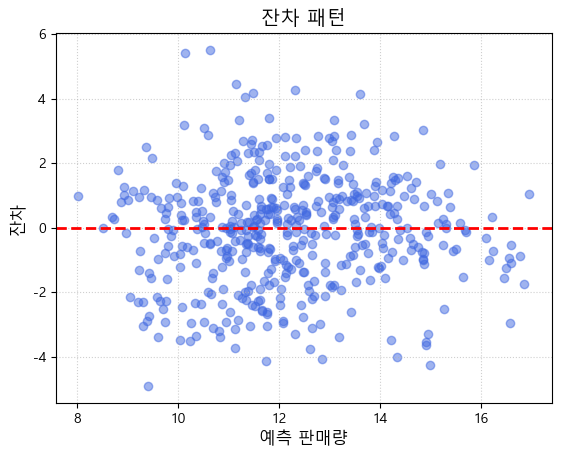

In [116]:
residuals_l = test_target.values - y_pred_l

plt.scatter(y_pred_l, residuals_l, alpha=0.5, color='royalblue')
plt.axhline(y=0, color='red', linestyle='--', linewidth=2) # 0 기준선

plt.title('잔차 패턴', fontsize=14)
plt.xlabel('예측 판매량', fontsize=12)
plt.ylabel('잔차', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

In [117]:
#회귀 분석이지만 해당 데이터에서 판매량 상위30%를 흥행작으로 가정하고 분류 모델 처럼 평가해서
#해당 머신러닝 모델의 성능을 평가
#Confusion Matrix와 ROC Curve시행

In [118]:
#Confusion Matrix
#진짜 비흥행을 맞힘: 망할 것 같은 게임 311개 정확히 예측
#진짜 흥행을 맞힘: 흥행할 것 같은 게임 76개 정확히 예측
#예측 실패: 실제로는 흥행한 67개의 게임에 대해 모델은 실패할 거라고 예측
#예측 실패: 실제로는 흥행하지 못한 22개의 게임에 대해 흥행할 것이라고 잘못 예측

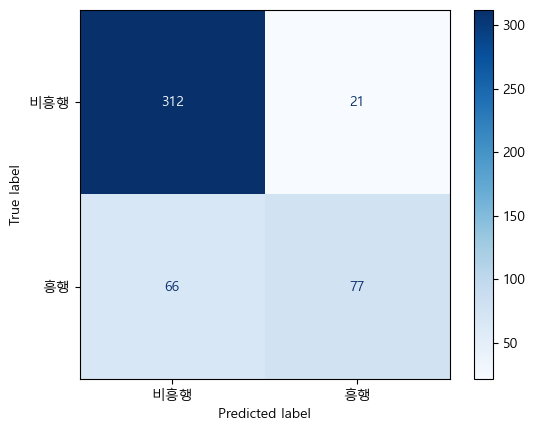

정확도: 81.7%
전체 게임 10개 중 8개 이상의 흥행여부 정확히 예측
정밀도: 78.6%
흥행예측이 78.6%의 확률로 성공


In [153]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
#상위 30퍼를 흥행으로 정의 하고 이를 넘는 값은 흥행(1)으로 나머지는 0으로 정의
threshold = np.percentile(test_target, 70)
y_actual_l = (test_target > threshold).astype(int)
y_pred_ll = (y_pred_l> threshold).astype(int)

cm_l = confusion_matrix(y_actual_l, y_pred_ll)
disp_l = ConfusionMatrixDisplay(confusion_matrix=cm_l, display_labels=['비흥행', '흥행'])
disp_l.plot(cmap='Blues', values_format='d')
plt.show()
tn_l, fp_l, fn_l, tp_l = cm_l.ravel()
print(f'정확도: {(tp_l + tn_l) / (tp_l + tn_l + fp_l + fn_l) * 100:,.1f}%')
print('전체 게임 10개 중 8개 이상의 흥행여부 정확히 예측')
print(f'정밀도: {tp_l / (tp_l + fp_l) * 100:,.1f}%')
print(f'흥행예측이 {tp_l / (tp_l + fp_l) * 100:,.1f}%의 확률로 성공')

In [120]:
#랏소 ROC Curve
#y축은 흥행작을 흥행작이라고 예측할 확률, x축은 흥행작이 아닌데 흥행작이라고 예측할 확률을 의미
#왼쪽 위 모서리에 곡선이 붙을 수 록 즉 흥행작만을 전부 골라 흥행작이라고 예측한다면 판별능력이 
#뛰어나다고 보고 AUC값은 곡선아래의 면적의 수치로 해당 모델은 0.8782로 준수하다고 할 수 있음
#즉 구체적인 판매량을 예측하는데는 오차가 있지만 어떤게임이 흥행할 것인지 판별하는 능력은 
#괜찮음을 알 수 있음

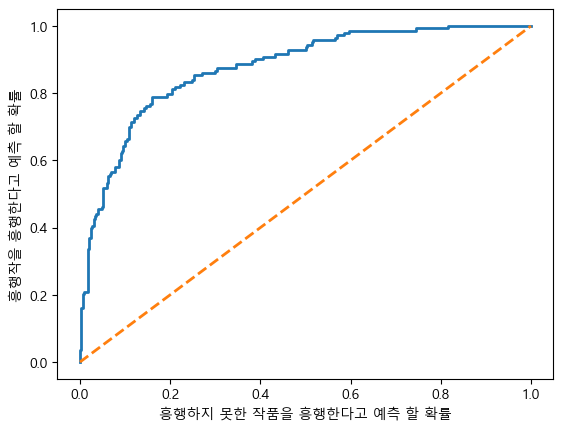

최종 AUC 점수: 0.8782


In [121]:
from sklearn.metrics import roc_curve, auc

# 회귀 모델의 예측값(y_pred)을 분류 확률값처럼 사용
fpr_l, tpr_l, thresholds = roc_curve(y_actual_l, y_pred_l)
roc_auc_l = auc(fpr_l, tpr_l)

plt.plot(fpr_l, tpr_l, lw=2)
plt.plot([0, 1], [0, 1], lw=2, linestyle='--') # 가이드라인

plt.xlabel('흥행하지 못한 작품을 흥행한다고 예측 할 확률')
plt.ylabel('흥행작을 흥행한다고 예측 할 확률')
plt.show()

print(f"최종 AUC 점수: {roc_auc_l:.4f}")

In [122]:
#랜덤 포레스트 알고리즘
#훈련 점수가 검증 변수와 비교했을때 매우 커 과대적합으로 보임
#하이퍼파라미터 튜닝이 필요해보임

In [123]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
rf= RandomForestRegressor(random_state=42)
rf_scores = cross_validate(rf, train_input, train_target, return_train_score=True)
rf_train_score=rf_scores['train_score'].mean()
rf_test_score=rf_scores['test_score'].mean()
print(f'훈련 점수 {rf_train_score:.4f}')
print(f'테스트 점수 {rf_test_score:.4f}')

훈련 점수 0.9505
테스트 점수 0.6428


In [124]:
#이산적인 후보군에서 벗어나고 하이퍼파라미터를 효율적으로 탐색하기 위해 베이지안 최적화 사용
#베이지안 최적화를 통해 최적의 파라미터(트리 모델의 깊이, 나무의 수 , 가지치기에 필요한 최소 샘플수)와
#그때의 검증 점수 구하기
#최적의 파라미터 값: 깊이-7 , 나무수-100, 가지치기에 필요한 최소 샘플수-100, 잎 노드의 최소 샘플 수-30

In [125]:
from skopt import BayesSearchCV
from skopt.space import Integer

In [126]:
search_spaces = {'n_estimators': Integer(100, 200),
    'max_depth': Integer(5, 7),
    'min_samples_split': Integer(100, 3000),
    'min_samples_leaf': Integer(30, 50)}
opt = BayesSearchCV(RandomForestRegressor(random_state=42),
    search_spaces, n_iter=30, cv=5, n_jobs=-1, random_state=42)
opt.fit(train_input, train_target)
print("베이지안 최적화 결과:", opt.best_params_)
print("최고 훈련 점수:", f'{opt.best_score_:.4f}')

베이지안 최적화 결과: OrderedDict([('max_depth', 7), ('min_samples_leaf', 30), ('min_samples_split', 100), ('n_estimators', 100)])
최고 훈련 점수: 0.5426


In [127]:
print(f"최종 테스트 점수: {opt.score(test_input, test_target):.4f}")

최종 테스트 점수: 0.5197


In [128]:
opt_t = opt.best_estimator_

In [129]:
#해당 모델에 사용된 변수의 중요도 추출
#랏소의 계수와 비교했을때 상위 3위 까지의 순위는 같으며 랏소에서 계수가 0으로 조정되었던 출시 월의 경우 
#랜덤포레스트에서는 비교적 높은 등수를 차지했고 대신 Open World, Survival, RPG, Tactical, Strategy, Sandbox
#이 중요도가 0으로 측정되었음, 또한 랜덤포레스트에서는 평가의 중요도가 4위로 높아졌고 난이도 등의 변수들의 순위가 달라졌음
#이는 랜덤포레스트가 랏소는 파악하지 못한 변수들의 비선형적 관계를 반영하여 중요도를 계산하기에 나온 결과
#반대로 랏소는 랜덤포레스트에서는 알 수 없는 변수들의 방향성을 알 수 있음

C:\Users\oyooy\AppData\Local\Temp\ipykernel_26004\2977373696.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='절대값_계수',y='변수', data=lasso_coef, palette=colors,ax=ax[0])
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


                       변수        계수    절대값_계수                     변수       중요도
0                  length  0.823065  0.823065                 length  0.418675
1                    year -0.682507  0.682507                   year  0.256653
2   log_review_efficiency -0.515769  0.515769  log_review_efficiency  0.104512
3        language_count_m  0.482023  0.482023                 rating  0.086751
4                   price  0.354352  0.354352       language_count_m  0.073294
5       reviews_like_rate  0.327178  0.327178                  price  0.029753
6                  rating  0.271981  0.271981      reviews_like_rate  0.014553
7                     FPS  0.237453  0.237453        age_restriction  0.009561
8                name_len -0.186796  0.186796             difficulty  0.001841
9              Open World  0.178328  0.178328               name_len  0.001594
10               Survival  0.151281  0.151281                    FPS  0.000881
11        age_restriction  0.145150  0.145150       

Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.
Font 'default' does not have a glyph for '\u2212' [U+2212], substituting with a dummy symbol.


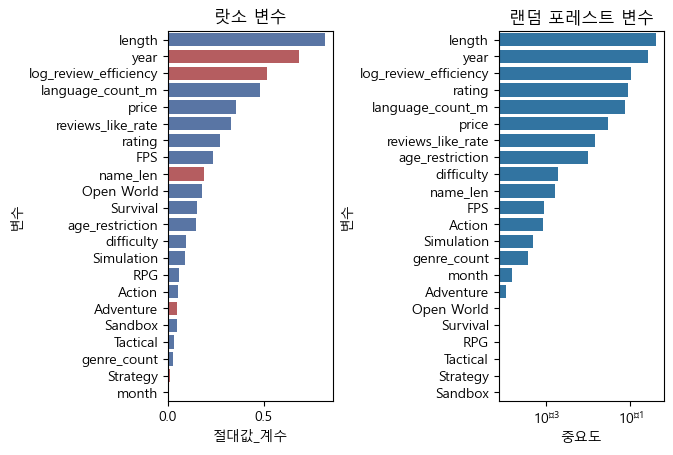

In [156]:
col_r = pd.DataFrame({'변수': features,
    '중요도': opt_t .feature_importances_})
rand_import=col_r.sort_values('중요도', ascending=False)
print(pd.concat([lasso_coef.reset_index(drop=True),
     rand_import.reset_index(drop=True)],axis=1))
fig, ax=plt.subplots(1,2)
sns.barplot(x='절대값_계수',y='변수', data=lasso_coef, palette=colors,ax=ax[0])
ax[0].set_title('랏소 변수')
sns.barplot(x='중요도',y='변수', data=rand_import,ax=ax[1])
#그래프상 중요도 수치 차이가 잘 나타나지 않아 그래프에서만 로그를 사용해서 표현
ax[1].set_xscale('log')
ax[1].set_title('랜덤 포레스트 변수')
plt.subplots_adjust(wspace=1)
plt.show()

In [131]:
#랜덤포레스트에서 중요도가 높은 상위 5개의 변수의 방향성 확인 하기 위해 PartialDependenceDisplay 사용
#출시 년도와 판매량 대비 리뷰수만 우하향하고 나머지는 우상향함
#즉 출시 년도와 판매량 대비 리뷰수는 값이 커질수록 판매량이 줄어들고
#나머지는 값이 커질수록 판매량도 늘어난다는 것을 알 수 있음

C:\Users\oyooy\anaconda3\envs\sstat\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 8 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(
C:\Users\oyooy\anaconda3\envs\sstat\Lib\site-packages\sklearn\inspection\_partial_dependence.py:721: FutureWarning: The column 1 contains integer data. Partial dependence plots are not supported for integer data: this can lead to implicit rounding with NumPy arrays or even errors with newer pandas versions. Please convert numerical featuresto floating point dtypes ahead of time to avoid problems. This will raise ValueError in scikit-learn 1.9.
  warnings.warn(


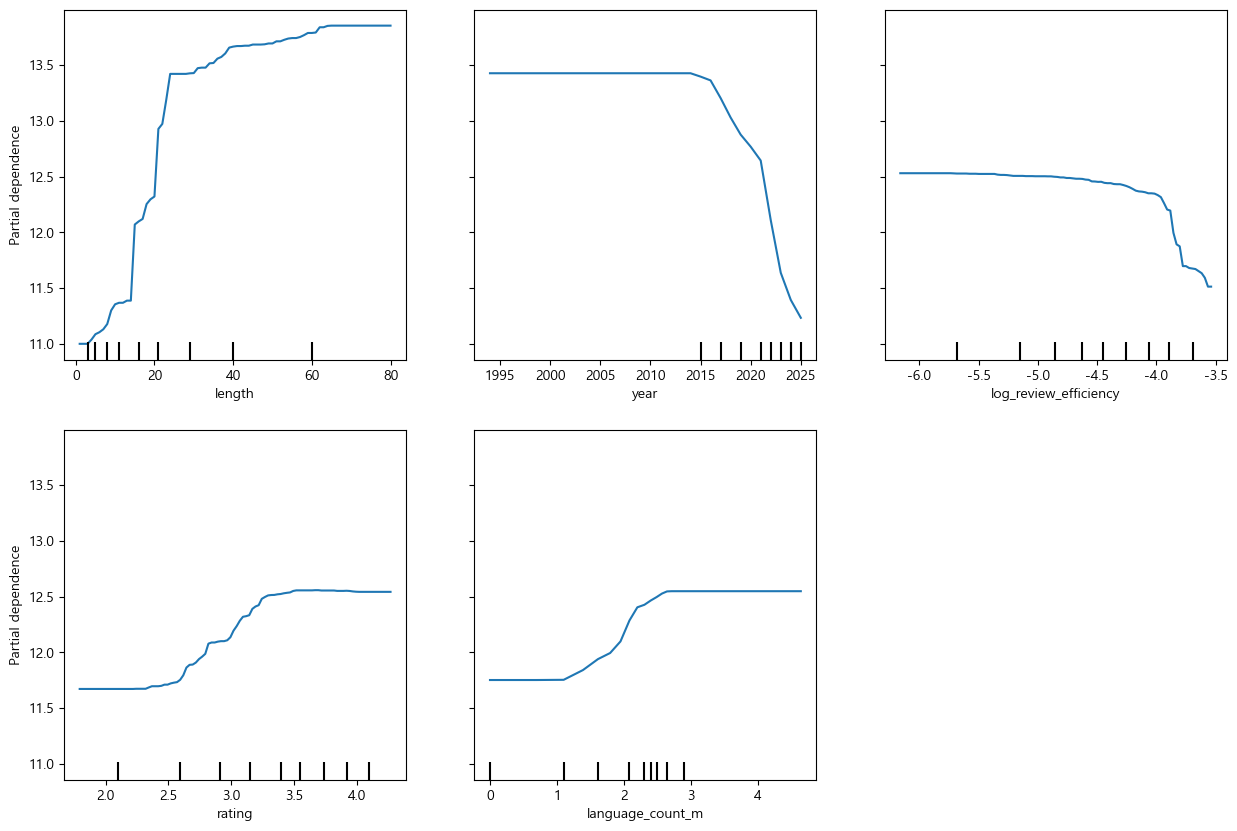

In [132]:
from sklearn.inspection import PartialDependenceDisplay

top_features = ['length', 'year', 'log_review_efficiency','rating','language_count_m']

# 3개를 한 번에 시각화
fig, ax = plt.subplots(figsize=(15, 10))
PartialDependenceDisplay.from_estimator(opt_t, train_input, top_features, ax=ax)
plt.show()

In [133]:
#랏소와 랜덤 포레스트의 테스트 점수를 비교하면 랏소의 예측력이 좋다는 것을 알 수 있음
#과대 적합 정도도 랏소가 더 낮아 판매량 예측에 랏소를 사용하는 게 적절해 보임
#그러나 두 알고리즘 모두 데이터를 절반 정도 밖에 설명하지 못하기 때문에 좀더 복잡하고
#정확한 데이터를 사용해서 다시 확인해야 할 것으로 보임

In [134]:
print(f"랏소 테스트 점수: {lasso.score(test_scaled, test_target)}")
print(f"랜덤 포레스트 테스트 점수: {opt.score(test_input, test_target)}")
print(f"랏소 과대 적합 정도: {lasso.score(train_scaled, train_target)- lasso.score(test_scaled, test_target)}")
print(f"랜덤 포레스트 과대적합 정도: {opt.score(test_input, test_target)-opt.best_score_}")

랏소 테스트 점수: 0.5304517750013205
랜덤 포레스트 테스트 점수: 0.5197027650553746
랏소 과대 적합 정도: 0.0138356138898732
랜덤 포레스트 과대적합 정도: -0.02293994188827575


In [135]:
#두 모델의 학습시간 비교
#랏소보다 랜덤 포레스트가 더 복잡한 알고리즘이기에 학습도 더 오랜시간 소비되었음

In [136]:
import time

start = time.time()
lasso.fit(train_scaled, train_target)
lasso_time = time.time() - start

start = time.time()
opt.fit(train_input, train_target) # 이미 튜닝된 파라미터로 학습
rf_time = time.time() - start

print(f"Lasso 학습 시간: {lasso_time:.4f}초")
print(f"Random Forest 학습 시간: {rf_time:.4f}초")

Lasso 학습 시간: 0.0010초
Random Forest 학습 시간: 17.3772초


In [159]:
#오분류 분석 비교
#모델에 따라 오차가 큰 상위 3개 게임도 다르게 나타나지만
#그래프에서 큰 차이는 없고 RMSE차이도 거의 없음

In [158]:
from sklearn.metrics import mean_squared_error
y_pred_r = opt.predict(test_input)

#테스트 세트에 대한 예측값과 실제 값, 그 차이
error_analysis_r = pd.DataFrame({
    '이름': d.loc[test_input.index, 'game_name'], 
    '실제 누적 판매량': test_target.values,
    '예상 누적 판매량': y_pred_r,
    '잔차 절대값': np.abs(test_target.values - y_pred_r)})
#RMSE 계산
rmse_l = np.sqrt(mean_squared_error(test_target, y_pred_l))
rmse_r = np.sqrt(mean_squared_error(test_target, y_pred_r))
print(f"Lasso: {rmse_l:,.2f}")
print(f"Random Forest: {rmse_r:,.2f}")

#오차가 가장 큰 상위 3개 샘플
top_errors_r = error_analysis_r.sort_values(by='잔차 절대값', ascending=False).head(3)
print("오차가 가장 큰 상위 3개 게임 랜덤 포레스트와 랏소")
print(pd.concat(
    [top_errors_r[['이름', '실제 누적 판매량', '예상 누적 판매량', '잔차 절대값']].reset_index(drop=True),
     top_errors_l[['이름', '실제 누적 판매량', '예상 누적 판매량', '잔차 절대값']].reset_index(drop=True)], axis=1))
top3_error_r = error_analysis_r.sort_values(by='잔차 절대값', ascending=False).head(3).index
top3_error_l = error_analysis_l.sort_values(by='잔차 절대값', ascending=False).head(3).index
print("\n오차가 가장 큰 상위 3개 게임(랜덤 포레스트)")
aa = list(features)
aa.insert(0,'game_name')
display(d.loc[top3_error_r, aa])
print('예측 한계')
print('''Lost Ark: 무료, 평범한 평가, 지원언어의 수도 적음에도 높은 판매량 
    - 한국 게임이란 특수성과 당시 경쟁작이던 WOW나 메이플스토리 등의 부진''')
print('''Unturned: 무료, 평범한 평가, 지원언어의 수도 적음에도 높은 판매량  
    - 마인크래프트와의 유사성으로 크게 화제, 출시 당시 인터넷 방송인들에 의해 크게 홍보되었음''')
print('''Buckshot Roulette: 평범한 평가, 비교적 작은 플레이타임 에도 높은 판매량
    - 멀티플레이 업데이트로 적은 플레이타임이 오히려 잘 맞았고 인터넷 방송인들에 의해 크게 홍보\n''')
print("\n오차가 가장 큰 상위 3개 게임(랏소)")
display(d.loc[top3_error_l, aa])
print('예측 한계')
print('''Business Tour - Board Game with Online Multiplayer: 이름이 매우 길고 무료, 연령제한 0세, 난이도도 낮은데 높은 판매량 
    - 저사양/캐주얼 장르로서 대중적''')
print('''Helltaker: 비교적 작은 플레이타임, 적은 지원언어의 수, 무료 이지만 높은 판매량
    - 매력적인 캐릭터 디자인, 매우 드문 저예산 인디게임 성공작이란 타이틀''')
print('''Mystopia: 최신작, 지원언어의 수도 적음에도 높은 판매량 
    - 가벼운 분위기, 아기자기한 디자인이 인기를 끌었음''')

Lasso: 1.70
Random Forest: 1.72
오차가 가장 큰 상위 3개 게임 랜덤 포레스트와 랏소
                  이름  실제 누적 판매량  예상 누적 판매량    잔차 절대값  \
0           Lost Ark  17.773271  12.808767  4.964505   
1           Unturned  17.897783  13.086590  4.811193   
2  Buckshot Roulette  15.603931  10.861417  4.742514   

                                                  이름  실제 누적 판매량  예상 누적 판매량  \
0  Business Tour - Board Game with Online Multipl...  16.134953  10.625860   
1                                          Helltaker  15.545395  10.133088   
2                                           Mystopia   4.499810   9.405087   

     잔차 절대값  
0  5.509092  
1  5.412306  
2  4.905278  

오차가 가장 큰 상위 3개 게임(랜덤 포레스트)


,game_name,log_review_efficiency,year,name_len,reviews_like_rate,price,age_restriction,rating,difficulty,length,...,Action,FPS,Survival,Open World,RPG,Simulation,Tactical,Strategy,Adventure,Sandbox
100,Lost Ark,-5.557347,2022,8,71,0.00,17,3.32,3,68,...,1,0,0,0,0,0,0,0,0,0
564,Unturned,-4.670702,2017,8,91,0.00,13,3.35,3,49,...,0,1,1,1,0,0,0,0,0,1
237,Buckshot Roulette,-4.270994,2024,17,96,1.49,13,3.54,1,3,...,0,0,0,0,0,1,0,1,0,0


예측 한계
Lost Ark: 무료, 평범한 평가, 지원언어의 수도 적음에도 높은 판매량 
    - 한국 게임이란 특수성과 당시 경쟁작이던 WOW나 메이플스토리 등의 부진
Unturned: 무료, 평범한 평가, 지원언어의 수도 적음에도 높은 판매량  
    - 마인크래프트와의 유사성으로 크게 화제, 출시 당시 인터넷 방송인들에 의해 크게 홍보되었음
Buckshot Roulette: 평범한 평가, 비교적 작은 플레이타임 에도 높은 판매량
    - 멀티플레이 업데이트로 적은 플레이타임이 오히려 잘 맞았고 인터넷 방송인들에 의해 크게 홍보


오차가 가장 큰 상위 3개 게임(랏소)


,game_name,log_review_efficiency,year,name_len,reviews_like_rate,price,age_restriction,rating,difficulty,length,...,Action,FPS,Survival,Open World,RPG,Simulation,Tactical,Strategy,Adventure,Sandbox
290,Business Tour - Board Game with Online Multipl...,-4.887087,2017,50,60,0.00,0,2.20,2,9,...,0,0,0,0,0,1,0,1,0,0
1321,Helltaker,-3.810743,2020,9,97,0.00,10,3.57,3,2,...,0,0,0,0,0,0,0,0,0,0
332,Mystopia,-2.014903,2025,8,100,4.99,10,4.36,2,13,...,0,0,0,0,0,0,0,0,0,1


예측 한계
Business Tour - Board Game with Online Multiplayer: 이름이 매우 길고 무료, 연령제한 0세, 난이도도 낮은데 높은 판매량 
    - 저사양/캐주얼 장르로서 대중적
Helltaker: 비교적 작은 플레이타임, 적은 지원언어의 수, 무료 이지만 높은 판매량
    - 매력적인 캐릭터 디자인, 매우 드문 저예산 인디게임 성공작이란 타이틀
Mystopia: 최신작, 지원언어의 수도 적음에도 높은 판매량 
    - 가벼운 분위기, 아기자기한 디자인이 인기를 끌었음


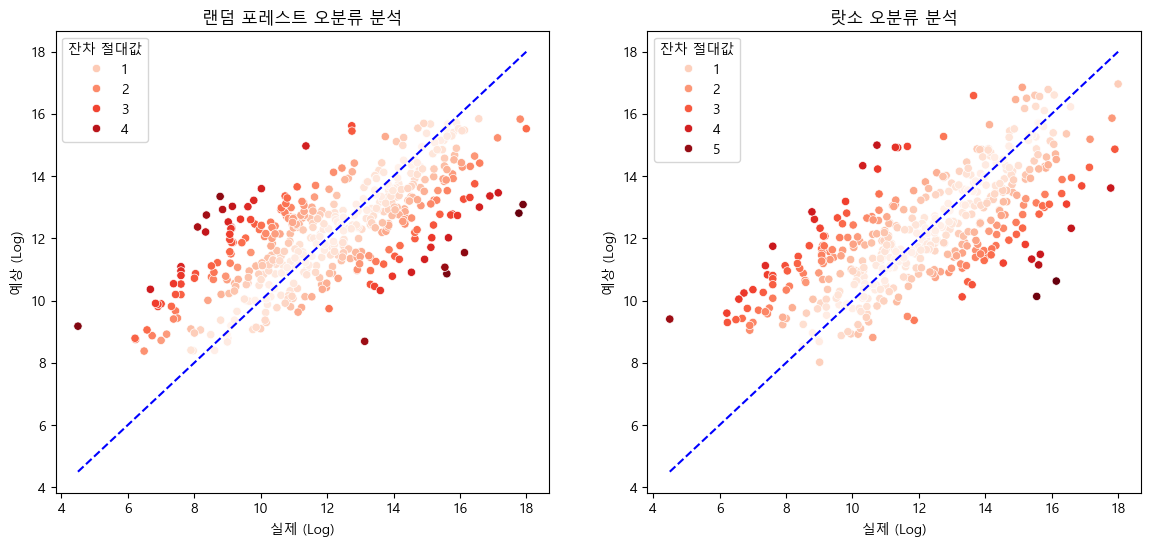

In [139]:
fig, ax = plt.subplots(1, 2, figsize=(14,6))
sns.scatterplot(data=error_analysis_r, x='실제 누적 판매량', y='예상 누적 판매량', hue='잔차 절대값', palette='Reds',ax=ax[0])
ax[0].plot([test_target.min(), test_target.max()], [test_target.min(), test_target.max()], color='blue', linestyle='--')
ax[0].set_title('랜덤 포레스트 오분류 분석')
ax[0].set_xlabel('실제 (Log)')
ax[0].set_ylabel('예상 (Log)')

sns.scatterplot(data=error_analysis_l, x='실제 누적 판매량', y='예상 누적 판매량', hue='잔차 절대값', palette='Reds',ax=ax[1])
ax[1].plot([test_target.min(), test_target.max()], [test_target.min(), test_target.max()], color='blue', linestyle='--', label='Perfect Prediction')
ax[1].set_title('랏소 오분류 분석')
ax[1].set_xlabel('실제 (Log)')
ax[1].set_ylabel('예상 (Log)')
plt.show()

In [140]:
#잔차 패턴 분석 비교
#두 모델의 잔차 패턴 모두 0을 중심으로 무작위적으로 분포 되어있으나
#유의미한 차이는 보이지 않음

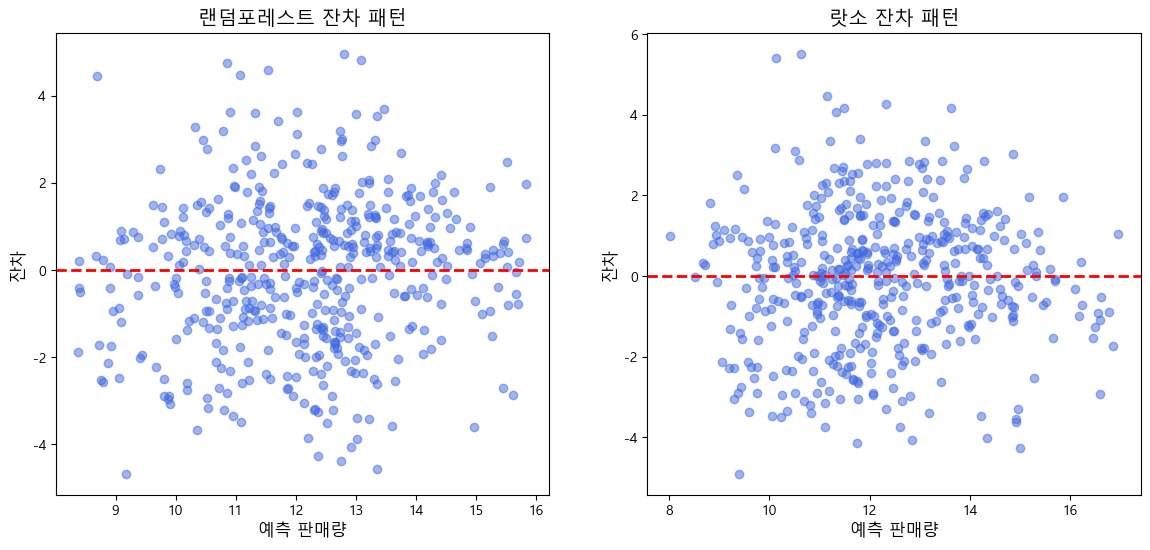

In [141]:
residuals_r = test_target.values - y_pred_r
fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].scatter(y_pred_r, residuals_r, alpha=0.5, color='royalblue')
ax[0].axhline(y=0, color='red', linestyle='--', linewidth=2) # 0 기준선
ax[0].set_title('랜덤포레스트 잔차 패턴', fontsize=14)
ax[0].set_xlabel('예측 판매량', fontsize=12)
ax[0].set_ylabel('잔차', fontsize=12)

ax[1].scatter(y_pred_l, residuals_l, alpha=0.5, color='royalblue')
ax[1].axhline(y=0, color='red', linestyle='--', linewidth=2) # 0 기준선
ax[1].set_title('랏소 잔차 패턴', fontsize=14)
ax[1].set_xlabel('예측 판매량', fontsize=12)
ax[1].set_ylabel('잔차', fontsize=12)
plt.show()

In [142]:
#잔차 분석을 통해 두 모델 모두 심각한 데이터 편향 없이 학습되었음을 검증하였으며
#오분류 분석을 통해 단순 수치만으로는 예측하기 어려운 특이 사례(Outlier)의 존재를 확인하여 
#모델의 예측 한계를 찾아냈음

In [143]:
#회귀 분석이지만 랏소 모델과 마찬가지로 해당 데이터에서 판매량 상위30%를 
#흥행작으로 가정하고 분류 모델 처럼 평가해서 해당 머신러닝 모델의 성능을 평가
#Confusion Matrix와 ROC Curve시행

In [144]:
#랜덤포레스트 Confusion Matrix
#진짜 비흥행을 맞힘: 망할 것 같은 게임 318개 정확히 예측
#진짜 흥행을 맞힘: 흥행할 것 같은 게임 67개 정확히 예측
#예측 실패: 실제로는 흥행한 76개의 게임에 대해 모델은 실패할 거라고 예측
#예측 실패: 실제로는 흥행하지 못한 15개의 게임에 대해 흥행할 것이라고 잘못 예측

#정확도는 랏소가 정밀도는 랜덤 포레스트가 높음
#즉 전체 게임에서 흥행, 비흥행 여부를 정확히 예측하는 것은 랏소가 뛰어나고
#흥행할 게임을 예측할때 그 예측의 신뢰도는 랜덤 포레스트가 더 뛰어남

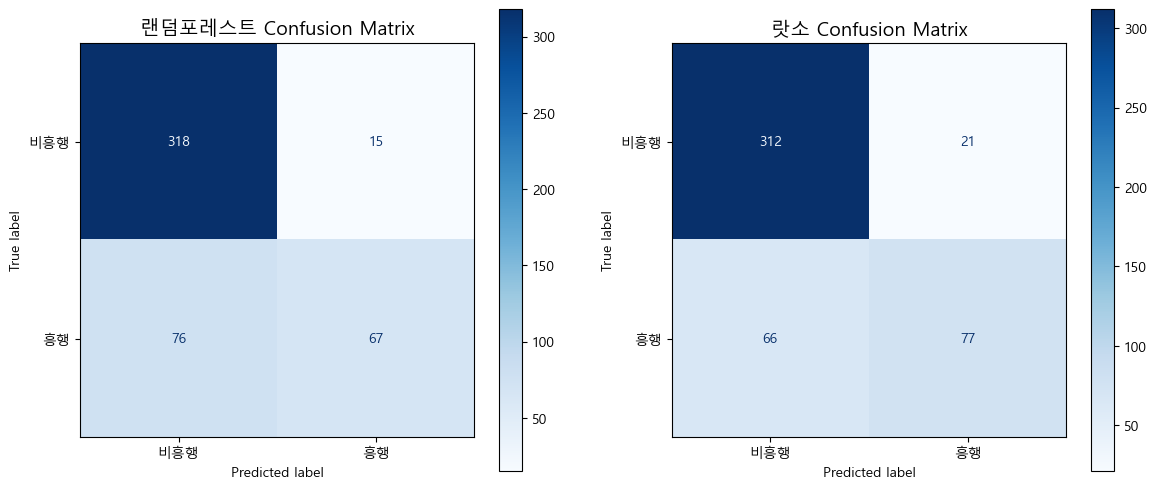

랜덤 포레스트 정확도: 80.9%
랏소 정확도: 81.7%
랜덤 포레스트 정밀도: 81.7%
랏소 정밀도: 78.6%


In [160]:
y_pred_rr = (y_pred_r> threshold).astype(int)
cm_r = confusion_matrix(y_actual_l, y_pred_rr)
disp_r = ConfusionMatrixDisplay(confusion_matrix=cm_r, display_labels=['비흥행', '흥행'])

fig, ax = plt.subplots(1, 2, figsize=(14,6))
disp_r.plot(cmap='Blues', values_format='d',ax=ax[0])
ax[0].set_title('랜덤포레스트 Confusion Matrix', fontsize=14)
disp_l.plot(cmap='Blues', values_format='d',ax=ax[1])
ax[1].set_title('랏소 Confusion Matrix', fontsize=14)
tn_r, fp_r, fn_r, tp_r = cm_r.ravel()
plt.show()
print(f'랜덤 포레스트 정확도: {(tp_r + tn_r) / (tp_r + tn_r + fp_r + fn_r)*100:,.1f}%')
print(f'랏소 정확도: {(tp_l + tn_l) / (tp_l + tn_l + fp_l + fn_l)*100:,.1f}%')
print(f'랜덤 포레스트 정밀도: {tp_r / (tp_r + fp_r) * 100:,.1f}%')
print(f'랏소 정밀도: {tp_l / (tp_l + fp_l) * 100:,.1f}%')

In [146]:
#랜덤포레스트 ROC Curve
#랜덤포레스트의 AUC값은 0.8788로 준수하고 랏소의 AUC값보다는 작아 랏소는 랜덤포레스트 보다
#실제 흥행작을 흥행작이라고 더 잘 예측

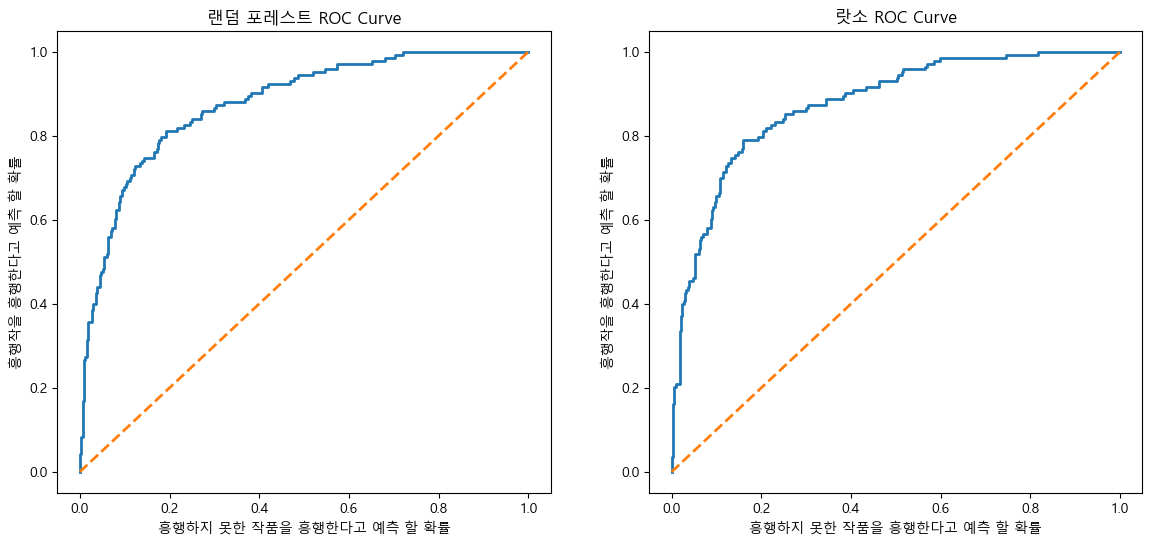

랜덤 포레스트 AUC 점수: 0.87824
랏소 AUC 점수: 0.87820


In [162]:
fpr_r, tpr_r, thresholds = roc_curve(y_actual_l, y_pred_r)
roc_auc_r = auc(fpr_r, tpr_r)

fig, ax = plt.subplots(1, 2, figsize=(14,6))
ax[0].plot(fpr_r, tpr_r, lw=2)
ax[0].plot([0, 1], [0, 1], lw=2, linestyle='--')
ax[0].set_xlabel('흥행하지 못한 작품을 흥행한다고 예측 할 확률')
ax[0].set_ylabel('흥행작을 흥행한다고 예측 할 확률')
ax[0].set_title('랜덤 포레스트 ROC Curve')

ax[1].plot(fpr_l, tpr_l, lw=2)
ax[1].plot([0, 1], [0, 1], lw=2, linestyle='--')
ax[1].set_xlabel('흥행하지 못한 작품을 흥행한다고 예측 할 확률')
ax[1].set_ylabel('흥행작을 흥행한다고 예측 할 확률')
ax[1].set_title('랏소 ROC Curve')
plt.show()

print(f"랜덤 포레스트 AUC 점수: {roc_auc_r:.5f}")
print(f"랏소 AUC 점수: {roc_auc_l:.5f}")

In [148]:
#추가적으로 게임 장르가 게임의 많은 요소를 결정 짓기에 게임의 장르와 다른 변수간 상호작용 효과를 분석하기로함
#랏소와 랜덤포레스트 모두에서 중요도가 높았던 변수 'length', 'year', 'log_review_efficiency','rating',
#'language_count','price','reviews_like_rate'를 사용

In [149]:
#랏소에서 장르와의 상호작용의 효과가 가장 큰 5개의 경우를 보면 먼저 reviews_like_rate_x_Simulation가 
#1등으로 시뮬레이션 장르에서는 유저들의 호감도가 흥행에 아주 강력한 영향을 미침
#2등, 3등은 year_x_Open World, year_x_FPS으로 Open World와 FPS는 시간이 흐를수록(최근일수록) 판매량에 
#덜 부정적인 영향을 미침, 랏소에서 year변수의 계수가 음수였던것과는 다른 결과가 나타님
#language_count_m_x_Survival은 4등으로 Survival의 경우 다양한 언어를 지원할수록 흥행에 긍정적 영향을 미침
#5등은 length_x_Action으로 Action은 플레이 타임이 길 때 흥행에 긍정적 영향을 미침

In [150]:
genre_cols = ['Action', 'FPS', 'Survival', 'Open World', 'RPG', 'Simulation', 'Tactical', 'Strategy', 'Adventure', 'Sandbox']
other_cols = ['length', 'year', 'log_review_efficiency','rating','language_count_m','price','reviews_like_rate']

d_lasso = d.copy()
interaction_cols = []

for num_var in other_cols:
    for genre in genre_cols:
        col_name = f"{num_var}_x_{genre}"
        d_lasso[col_name] = d_lasso[num_var] * d_lasso[genre]
        interaction_cols.append(col_name)
        
x_lasso = d_lasso[other_cols + genre_cols + interaction_cols].fillna(0)
y = d_lasso['log_downloads']

scaler = StandardScaler()
x_lasso_scaled = scaler.fit_transform(x_lasso)

lasso = Lasso(alpha=0.01) 
lasso.fit(x_lasso_scaled, y)

lasso_coefs = pd.Series(lasso.coef_, index=x_lasso.columns)
interaction_results = lasso_coefs[interaction_cols].sort_values(ascending=False)

print("--- [Lasso] 상호작용항 계수 결과 (Top 5) ---")
print(interaction_results[interaction_results != 0].head(5))

--- [Lasso] 상호작용항 계수 결과 (Top 5) ---
reviews_like_rate_x_Simulation    0.198978
year_x_Open World                 0.190347
language_count_m_x_Tactical       0.150610
language_count_m_x_Action         0.142909
log_review_efficiency_x_Action    0.133451
dtype: float64


In [151]:
#마지막으로 랜덤포레스트의 경우 상호작용 효과가 직접드러나지 않기에 shap을 이용해 따로 표현
#이때 shap은 해당 변수가 종속변수(판매량)에 기여한 점수를 말하며, 실제 변수 값이 커질 때 SHAP 점수가 얼마나 
#가파르게 상승하는지를 그래프로 표현했을때 기울기가 클수록 그 변수가 흥행에 주는 영향력이 크다는 것을 의미
#그러므로 지정한 장르를 지원하는 경우와 아닌경우의 기울기를 비교해 그 차이가 큰 경우가 상호작용효과가 크다고 할 수 있음
#여기서는 지정된 장르를 지원하는 게임의 변수와 판매량의 기울기 값 차이가 가장 큰 5가지의 경우를 살펴보기로 함
#여기서 기울기는 독립 변수(예: 플레이 타임, 출시 연도 등)의 수치가 1단위 변화할 때 SHAP 기여도가 변화하는 속도를 의미하며
#최대 기여도는 분석 대상 데이터셋 내에서 특정 변수가 개별 게임의 흥행 예측 점수를 상승시킨 최대 수치를 의미함
#여기서 랏소와 랜덤포레스트의 상호작용 효과가 높은 경우가 서로 완전히 다름을 알 수 있음
#log_review_efficiency x Survival가 1등, log_review_efficiency x Sandbox가 3등 으로 서바이벌과 오픈월드의 경우 판매량 대비 리뷰수가 
#클 수록 판매량에 더욱 부정적 영향을 미치며 year x RPG는 2등, year x Survival은 4등 으로 오래된 게임일 수록 
#판매량이 높은 성향 즉 최신작이 고전작의 인기를 넘지 못하는 경우가 더 많다는 것을 알 수 있음
#language_count_m x Open World는 5등으로 언어 지원을 많이 할수록 얻는 이득(가산점)"이 다른 장르보다 오픈 월드에서 훨씬 큼


기울기 차이 기반 상호작용 TOP 5
1: log_review_efficiency x Survival (기울기 차이: 1.42배, 최대기여도: 1.09)


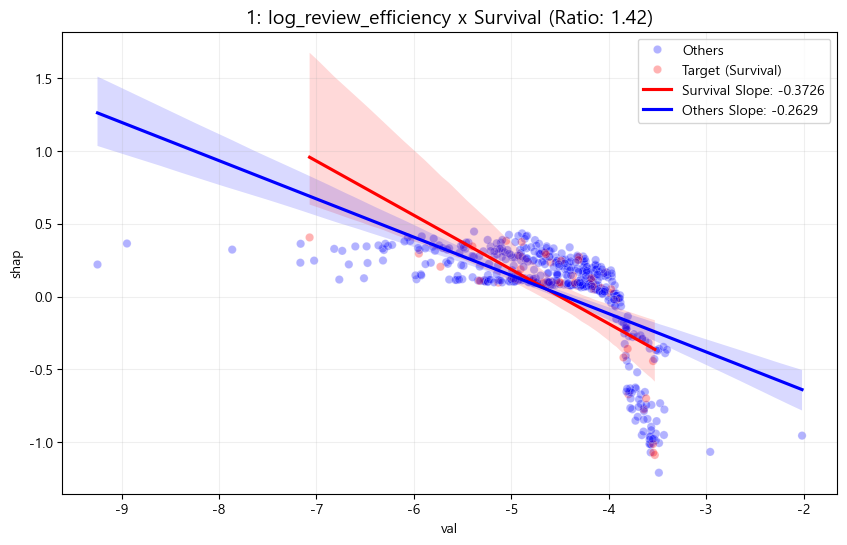

2: year x RPG (기울기 차이: 1.39배, 최대기여도: 1.31)


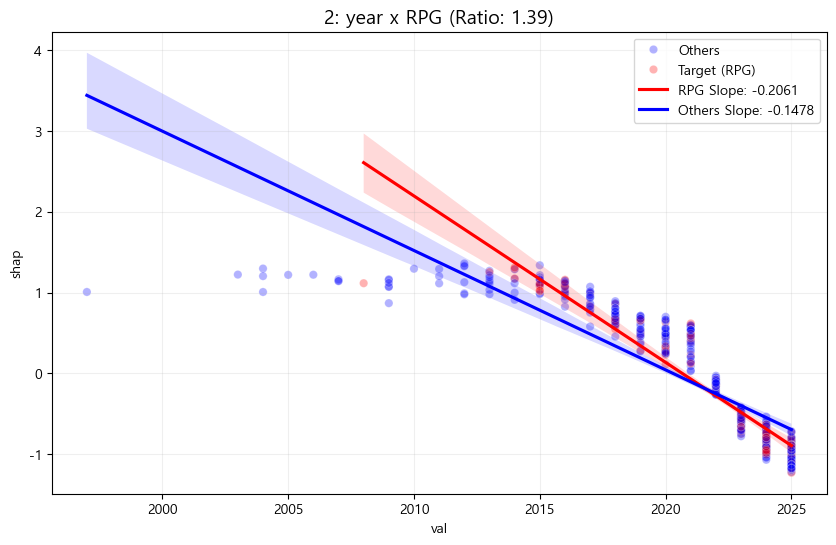

3: log_review_efficiency x Sandbox (기울기 차이: 1.38배, 최대기여도: 1.09)


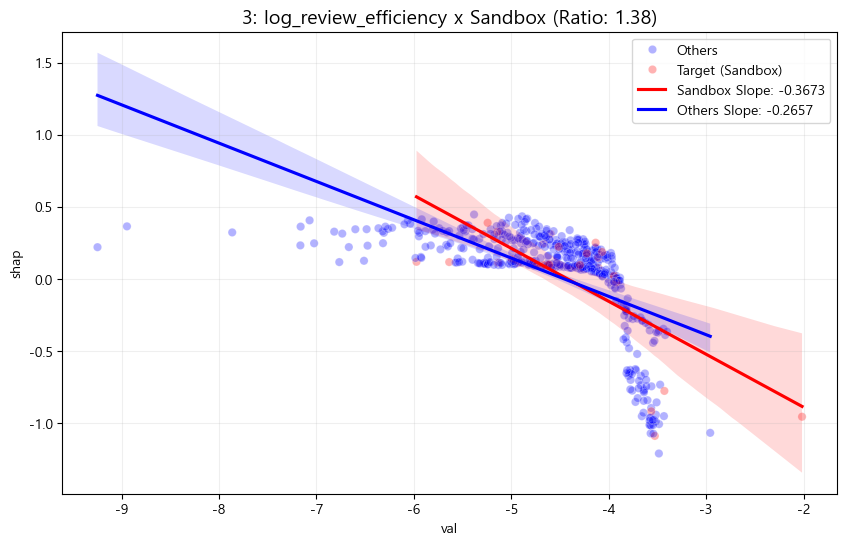

4: year x Survival (기울기 차이: 1.28배, 최대기여도: 1.16)


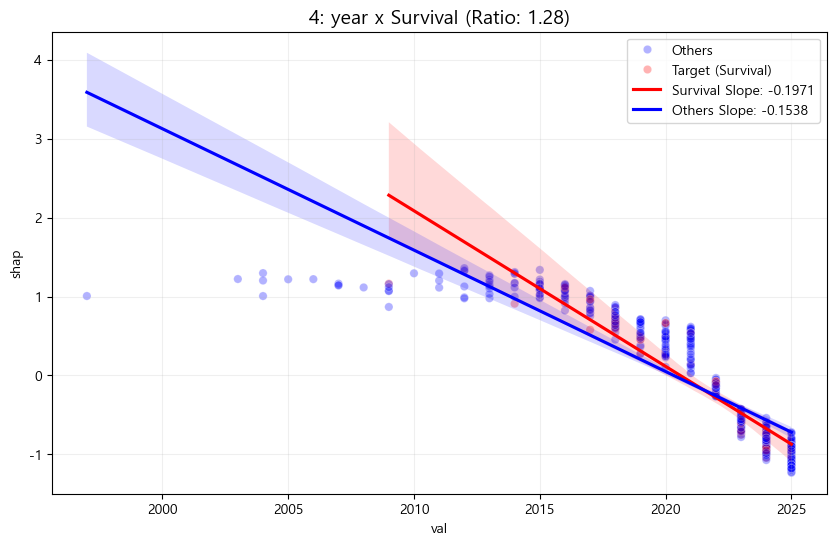

5: language_count_m x Open World (기울기 차이: 1.28배, 최대기여도: 0.96)


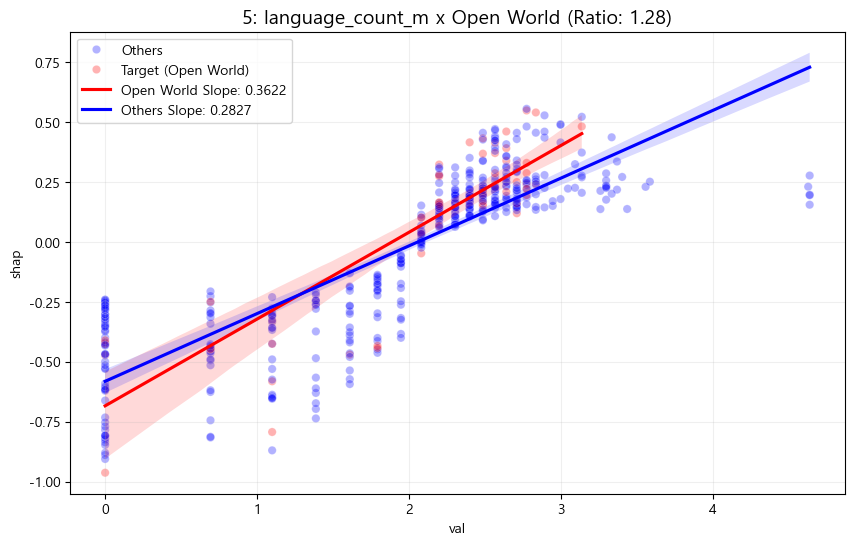

In [152]:
import shap
from sklearn.linear_model import LinearRegression

genre_cols = ['Action', 'FPS', 'Survival', 'Open World', 'RPG', 'Simulation', 'Tactical', 'Strategy', 'Adventure', 'Sandbox']
other_cols = ['length', 'year', 'log_review_efficiency','rating','language_count_m','price','reviews_like_rate']

X_rf = test_input 
best_model = opt_t
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_rf)

sv = shap_values[1] if isinstance(shap_values, list) else shap_values
interaction_results = []

for var in other_cols:
    var_idx = list(X_rf.columns).index(var)
    cur_shap = sv[:, var_idx]
    
    for genre in genre_cols:
        is_genre = (X_rf[genre] == 1)
        not_genre = (X_rf[genre] == 0)
        
        if is_genre.sum() < 10: continue 
        
        model_g = LinearRegression().fit(X_rf.loc[is_genre, [var]], cur_shap[is_genre])
        model_o = LinearRegression().fit(X_rf.loc[not_genre, [var]], cur_shap[not_genre])
        
        slope_g = model_g.coef_[0]
        slope_o = model_o.coef_[0]
        
        ratio = abs(slope_g) / (abs(slope_o) if abs(slope_o) > 1e-9 else 1e-9)
        max_impact = np.max(np.abs(cur_shap[is_genre]))
        
        interaction_results.append({'var': var,'genre': genre,'slope_g': slope_g,'slope_o': slope_o,
            'ratio': ratio,'max_impact': max_impact,'cur_shap': cur_shap})

#기울기 차이(ratio)가 큰 순서대로 상위 5개 정렬
top_5_final = sorted(interaction_results, key=lambda x: x['ratio'], reverse=True)[:5]

print("\n기울기 차이 기반 상호작용 TOP 5")

for i, res in enumerate(top_5_final):
    var, genre = res['var'], res['genre']
    print(f"{i+1}: {var} x {genre} (기울기 차이: {res['ratio']:.2f}배, 최대기여도: {res['max_impact']:.2f})")
    
    plt.figure(figsize=(10, 6))
    temp_df = pd.DataFrame({'val': X_rf[var], 'shap': res['cur_shap'], 
        'group': X_rf[genre].map({1: f'Target ({genre})', 0: 'Others'})})
    
    sns.scatterplot(data=temp_df, x='val', y='shap', hue='group', 
                    palette={f'Target ({genre})':'red', 'Others':'blue'}, alpha=0.3)
    
    sns.regplot(data=temp_df[temp_df['group']==f'Target ({genre})'], x='val', y='shap', 
                scatter=False, color='red', label=f"{genre} Slope: {res['slope_g']:.4f}")
    sns.regplot(data=temp_df[temp_df['group']=='Others'], x='val', y='shap', 
                scatter=False, color='blue', label=f"Others Slope: {res['slope_o']:.4f}")
    
    plt.title(f"{i+1}: {var} x {genre} (Ratio: {res['ratio']:.2f})", fontsize=14)
    plt.grid(True, alpha=0.2)
    plt.legend()
    plt.show()

In [165]:
#분석 결과 요약
#두 모델 모두 R² 약 0.5 수준으로 판매량 변동의 절반 정도를 설명 
#라쏘 기준 발매년도, 플레이타임, 지원언어 수가 중요한 변수로 나타났고
#랜덤 포레스트의 경우 상위권은 같으나 변수의 순위 차이 존재 
#발매월은 랏소에서 의미 없는 변수로 제거되었지만 
#랜덤포레스트에서는 무의미한 정도지만 중요도가 0보다 큼
#흥행 여부 판별 능력은 모두 준수하고 auc를 기준으로 보면 큰 차이가 없음

In [166]:
#한계
#R²가 0.5 수준으로 판매량의 절반밖에 설명하지 못함
#인터넷 방송인 홍보 등 변수로 반영하지 못한 특성이 다수 존재
#오분류 분석 통해 판매량이 높은 게임을 과소평가하는 경향 확인
#데이터가 스팀, GameFAQs, SteamDB로 분산되어 있어 정확도가 불확실함

In [167]:
#발견한 인사이트
#게임은 시장에 오래 살아남는 것이 판매량 확보에 유리함 (발매년도 계수 음수) 
#숏폼이 유행하는 미디어 시장과 달리 게임 이용자들은 긴 콘텐츠를 선호 
#스팀이 전세계 플랫폼인 만큼 다양한 언어 지원이 판매량에 중요한 영향을 미침
 
#장르별로 판매량에 영향을 미치는 변수가 다름 
#(시뮬레이션은 좋아요 비율, Open World/FPS는 최신작일수록 유리) 
#판매량 대비 리뷰수가 많은 게임은 특정 매니아층에만 소비됨으로 해석
#FPS 장르의 계수가 가장 크고 Adventure, Strategy는 음수로 장르 자체가 판매량에 영향을 미침 

In [168]:
#원래 목표와 달라진 점
#원래 목표는 게임 특성이 판매량에 미치는 영향을 파악하는 것이었는데, 
#    분석 과정에서 장르별 상호작용 효과 분석과 SHAP을 이용한 
#    랜덤포레스트 상호작용 분석까지 추가로 진행하면서 
#   단순 변수 영향력을 넘어 장르와 다른 변수의 결합 효과까지 파악했음


In [169]:
#개선 방향
#장르별로, 연도별로 데이터를 나눠서 각 분석하기 위해 출처가 
#    더 명확하고 사례수가 더 많은 데이터 구하기
#기존 모델에 포함되지 않은 변수를 포함시켜 더 복잡한 알고리즘을 적용

In [170]:
#느낀점
#처음 해보는 활동이어서 어설픈 점과 결함이 진행하면서 스스로 느껴졌지만 이를 딱히
#해결할 수 있는 방법이 보이지 않아 무작정 진행한것 같아 아쉬움이 남았음
#하지만 모델을 만들고 인사이틑 뽑아내는 것에서 흥미를 느꼈고 
#더 나아가서 정말 쓸모있는 모델을 만들고 싶다는 욕심이 생겼음